<a href="https://colab.research.google.com/github/phuc1909-web/Data_Mining_and_Machine_Learning_USTH/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_train='/content/drive/My Drive/train.csv'
chunk_size=200000
sample_rate=0.10
chunks=[]
for chunk in pd.read_csv(data_train, chunksize=chunk_size, low_memory=False):
  df=chunk.sample(frac=sample_rate, random_state=42)
  chunks.append(df)
df_train=pd.concat(chunks, ignore_index=True)
print(df_train.head())
print(df_train.info())

   fecha_dato  ncodpers ind_empleado pais_residencia sexo  age  fecha_alta  \
0  2015-01-28    992094            N              ES    V   45  2011-12-09   
1  2015-01-28   1093982            N              ES    V   26  2012-11-02   
2  2015-01-28   1291657            N              ES    V   21  2014-08-04   
3  2015-01-28   1070924            N              ES    H   23  2012-10-01   
4  2015-01-28   1038651            N              ES    V   23  2012-08-01   

   ind_nuevo antiguedad  indrel  ... ind_hip_fin_ult1 ind_plan_fin_ult1  \
0        0.0         43     1.0  ...                0                 0   
1        0.0         32     1.0  ...                0                 0   
2        0.0         12     1.0  ...                0                 0   
3        0.0         33     1.0  ...                0                 0   
4        0.0         35     1.0  ...                0                 0   

  ind_pres_fin_ult1 ind_reca_fin_ult1 ind_tjcr_fin_ult1 ind_valo_fin_ult1  \
0  

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   fecha_dato             1271586 non-null  object 
 1   ncodpers               1271586 non-null  int64  
 2   ind_empleado           1268792 non-null  object 
 3   pais_residencia        1268792 non-null  object 
 4   sexo                   1268788 non-null  object 
 5   age                    1271586 non-null  object 
 6   fecha_alta             1268792 non-null  object 
 7   ind_nuevo              1268792 non-null  float64
 8   antiguedad             1271586 non-null  object 
 9   indrel                 1268792 non-null  float64
 10  ult_fec_cli_1t         2275 non-null     object 
 11  indrel_1mes            1257136 non-null  object 
 12  tiprel_1mes            1257136 non-null  object 
 13  indresi                1268792 non-null  object 
 14  indext            

In [ ]:
df_train.rename(columns={
    'fecha_dato': 'date',
    'ncodpers': 'customer_id',
    'ind_empleado': 'employee_index',
    'pais_residencia': 'country',
    'sexo': 'gender',
    'age' : 'age',
    'fecha_alta': 'join_date',
    'ind_nuevo': 'new_customer',
    'antiguedad': 'seniority',
    'indrel': 'customer_type',
    'ult_fec_cli_1t': 'last_primary_date',
    'indrel_1mes': 'customer_relation_month_start',
    'tiprel_1mes': 'relation_type',
    'indresi': 'resident',
    'indext': 'foreigner',
    'conyuemp': 'employee_spouse',
    'canal_entrada': 'join_channel',
    'indfall': 'deceased',
    'tipodom': 'address_type',
    'cod_prov': 'province_code',
    'nomprov': 'provience',
    'ind_actividad_cliente': 'active_customer',
    'renta': 'income',
    'segmento': 'segment',
    'ind_ahor_fin_ult1': 'product_saving_account',
    'ind_aval_fin_ult1': 'product_guarantees',
    'ind_cco_fin_ult1': 'product_current_account',
    'ind_cder_fin_ult1': 'product_Derivada_account',
    'ind_cno_fin_ult1': 'product_payroll_account',
    'ind_ctju_fin_ult1': 'product_junior_account',
    'ind_ctma_fin_ult1': 'product_más_particular_account',
    'ind_ctop_fin_ult1': 'product_particular_account',
    'ind_ctpp_fin_ult1': 'product_particular+_account',
    'ind_deco_fin_ult1': 'product_short_deposit',
    'ind_deme_fin_ult1': 'product_medium_deposit',
    'ind_dela_fin_ult1': 'product_long_deposit',
    'ind_ecue_fin_ult1': 'product_e_account',
    'ind_fond_fin_ult1': 'product_funds',
    'ind_hip_fin_ult1': 'product_mortgage',
    'ind_plan_fin_ult1': 'product_pensions_plan',
    'ind_pres_fin_ult1': 'product_loans',
    'ind_reca_fin_ult1': 'product_taxes',
    'ind_tjcr_fin_ult1': 'product_credit_card',
    'ind_valo_fin_ult1': 'product_security',
    'ind_viv_fin_ult1': 'product_home_account',
    'ind_nomina_ult1': 'product_payroll',
    'ind_nom_pens_ult1': 'product_pensions',
    'ind_recibo_ult1': 'product_direct_debit'
}, inplace=True)

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   date                            1271586 non-null  object 
 1   customer_id                     1271586 non-null  int64  
 2   employee_index                  1268792 non-null  object 
 3   country                         1268792 non-null  object 
 4   gender                          1268788 non-null  object 
 5   age                             1271586 non-null  object 
 6   join_date                       1268792 non-null  object 
 7   new_customer                    1268792 non-null  float64
 8   seniority                       1271586 non-null  object 
 9   customer_type                   1268792 non-null  float64
 10  last_primary_date               2275 non-null     object 
 11  customer_relation_month_start   1257136 non-null  object 
 12  

In [ ]:
product_col_train=[]
for c in df_train.columns:
  if c.startswith('product_'):
    product_col_train.append(c)
print(product_col_train)

['product_saving_account', 'product_guarantees', 'product_current_account', 'product_Derivada_account', 'product_payroll_account', 'product_junior_account', 'product_más_particular_account', 'product_particular_account', 'product_particular+_account', 'product_short_deposit', 'product_medium_deposit', 'product_long_deposit', 'product_e_account', 'product_funds', 'product_mortgage', 'product_pensions_plan', 'product_loans', 'product_taxes', 'product_credit_card', 'product_security', 'product_home_account', 'product_payroll', 'product_pensions', 'product_direct_debit']


In [ ]:
#adjusting column's datatype
df_train[product_col_train]=df_train[product_col_train].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int32')
df_train['age']=pd.to_numeric(df_train['age'], errors='coerce').astype('float32')
df_train['income']=pd.to_numeric(df_train['income'], errors='coerce').astype('float32')
df_train['date']=pd.to_datetime(df_train['date'])
df_train['join_date']=pd.to_datetime(df_train['join_date'])

In [ ]:
print(df_train.shape)
df_train.head(10)

(1271586, 48)


,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pensions_plan,product_loans,product_taxes,product_credit_card,product_security,product_home_account,product_payroll,product_pensions,product_direct_debit
0,2015-01-28,992094,N,ES,V,45.0,2011-12-09,0.0,43,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1093982,N,ES,V,26.0,2012-11-02,0.0,32,1.0,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1291657,N,ES,V,21.0,2014-08-04,0.0,12,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-28,1070924,N,ES,H,23.0,2012-10-01,0.0,33,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-28,1038651,N,ES,V,23.0,2012-08-01,0.0,35,1.0,...,0,0,0,0,0,0,0,0,0,0
5,2015-01-28,1026595,N,ES,H,23.0,2012-07-20,0.0,36,1.0,...,0,0,0,0,0,0,0,0,0,0
6,2015-01-28,998858,N,ES,H,23.0,2011-12-23,0.0,43,1.0,...,0,0,0,0,0,0,0,0,0,0
7,2015-01-28,1266548,N,ES,H,42.0,2014-07-01,0.0,12,1.0,...,0,0,0,0,0,0,0,0,0,1
8,2015-01-28,995133,N,ES,H,23.0,2011-12-16,0.0,43,1.0,...,0,0,0,0,0,0,0,0,0,0
9,2015-01-28,1052481,N,ES,H,24.0,2012-08-17,0.0,35,1.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   date                            1271586 non-null  datetime64[ns]
 1   customer_id                     1271586 non-null  int64         
 2   employee_index                  1268792 non-null  object        
 3   country                         1268792 non-null  object        
 4   gender                          1268788 non-null  object        
 5   age                             1268792 non-null  float32       
 6   join_date                       1268792 non-null  datetime64[ns]
 7   new_customer                    1268792 non-null  float64       
 8   seniority                       1271586 non-null  object        
 9   customer_type                   1268792 non-null  float64       
 10  last_primary_date               2275 non-n

In [ ]:
missing_train=df_train.isnull().sum()
missing_train_pct=(missing_train/len(df_train) *100).round(2)
report=pd.DataFrame({
    'missing': missing_train,
    'missing_pct':missing_train_pct
}).query('missing>0').sort_values('missing_pct', ascending=False)
print(report)

                               missing  missing_pct
employee_spouse                1271432        99.99
last_primary_date              1269311        99.82
income                          255875        20.12
segment                          17979         1.41
join_channel                     17690         1.39
customer_relation_month_start    14450         1.14
relation_type                    14450         1.14
provience                         8996         0.71
province_code                     8996         0.71
employee_index                    2794         0.22
age                               2794         0.22
gender                            2798         0.22
country                           2794         0.22
join_date                         2794         0.22
resident                          2794         0.22
customer_type                     2794         0.22
new_customer                      2794         0.22
foreigner                         2794         0.22
deceased    

In [ ]:
df_train['seniority']=pd.to_numeric(df_train['seniority'], errors='coerce')
df_train['seniority']=df_train['seniority'].clip(lower=0).astype('float32')
print(df_train['seniority'])

0          43.0
1          32.0
2          12.0
3          33.0
4          35.0
           ... 
1271581    28.0
1271582    29.0
1271583    28.0
1271584    28.0
1271585    18.0
Name: seniority, Length: 1271586, dtype: float32


In [ ]:
invalid_age=df_train[(df_train['age']<18)|(df_train['age']>100)]
print(len(invalid_age))
df_train['age']= df_train['age'].clip(lower=18, upper=100)
print(df_train['age'])


12440
0          45.0
1          26.0
2          21.0
3          23.0
4          23.0
           ... 
1271581    23.0
1271582    52.0
1271583    27.0
1271584    28.0
1271585    67.0
Name: age, Length: 1271586, dtype: float32


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   date                            1271586 non-null  datetime64[ns]
 1   customer_id                     1271586 non-null  int64         
 2   employee_index                  1268792 non-null  object        
 3   country                         1268792 non-null  object        
 4   gender                          1268788 non-null  object        
 5   age                             1268792 non-null  float32       
 6   join_date                       1268792 non-null  datetime64[ns]
 7   new_customer                    1268792 non-null  float64       
 8   seniority                       1268792 non-null  float32       
 9   customer_type                   1268792 non-null  float64       
 10  last_primary_date               2275 non-n

In [ ]:
df_train[product_col_train].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 24 columns):
 #   Column                          Non-Null Count    Dtype
---  ------                          --------------    -----
 0   product_saving_account          1271586 non-null  int32
 1   product_guarantees              1271586 non-null  int32
 2   product_current_account         1271586 non-null  int32
 3   product_Derivada_account        1271586 non-null  int32
 4   product_payroll_account         1271586 non-null  int32
 5   product_junior_account          1271586 non-null  int32
 6   product_más_particular_account  1271586 non-null  int32
 7   product_particular_account      1271586 non-null  int32
 8   product_particular+_account     1271586 non-null  int32
 9   product_short_deposit           1271586 non-null  int32
 10  product_medium_deposit          1271586 non-null  int32
 11  product_long_deposit            1271586 non-null  int32
 12  product_e_account           

In [ ]:
df_train['date']= pd.to_datetime(df_train['date'])
df_train['join_date'] = pd.to_datetime(df_train['join_date'])
df_train['age']= df_train['age'].astype('float32')
df_train['income']=pd.to_numeric(df_train['income'], errors='coerce').astype('float32')
df_train['seniority']= pd.to_numeric(df_train['seniority'], errors='coerce').astype('float32')
df_train['gender']=df_train['gender'].astype(str).str.strip().replace('nan', np.nan)
df_train['gender']=df_train['gender'].where(df_train['gender'].isin(['H', 'V']), np.nan)
product_cols =[c for c in df.columns if c.startswith('product_')]
df_train[product_cols]=(df_train[product_cols]
                  .apply(pd.to_numeric, errors='coerce')
                  .fillna(0)
                  .astype('int8'))

cat_cols=['gender', 'segment', 'relation_type', 'employee_index', 'country']
for col in cat_cols:
    df_train[col]=df_train[col].astype('category')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   date                            1271586 non-null  datetime64[ns]
 1   customer_id                     1271586 non-null  int64         
 2   employee_index                  1268792 non-null  category      
 3   country                         1268792 non-null  category      
 4   gender                          1268788 non-null  category      
 5   age                             1268792 non-null  float32       
 6   join_date                       1268792 non-null  datetime64[ns]
 7   new_customer                    1268792 non-null  float64       
 8   seniority                       1268792 non-null  float32       
 9   customer_type                   1268792 non-null  float64       
 10  last_primary_date               2275 non-n

In [ ]:
dup_customer_month_train=df_train.duplicated(subset=['customer_id', 'date']).sum()
dup_rows=df.duplicated().sum()
if dup_customer_month_train>0:
  df_train.drop_duplicates(subset=['customer_id', 'date'], keep='last')
else:
  print("0 dups")

0 dups


In [ ]:
df_clean_train=df_train.drop(columns=['employee_spouse'])
#missing_pct of employee_spouse column is 99.99%
df_clean_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 47 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   date                            1271586 non-null  datetime64[ns]
 1   customer_id                     1271586 non-null  int64         
 2   employee_index                  1268792 non-null  category      
 3   country                         1268792 non-null  category      
 4   gender                          1268788 non-null  category      
 5   age                             1268792 non-null  float32       
 6   join_date                       1268792 non-null  datetime64[ns]
 7   new_customer                    1268792 non-null  float64       
 8   seniority                       1268792 non-null  float32       
 9   customer_type                   1268792 non-null  float64       
 10  last_primary_date               2275 non-n

EDA

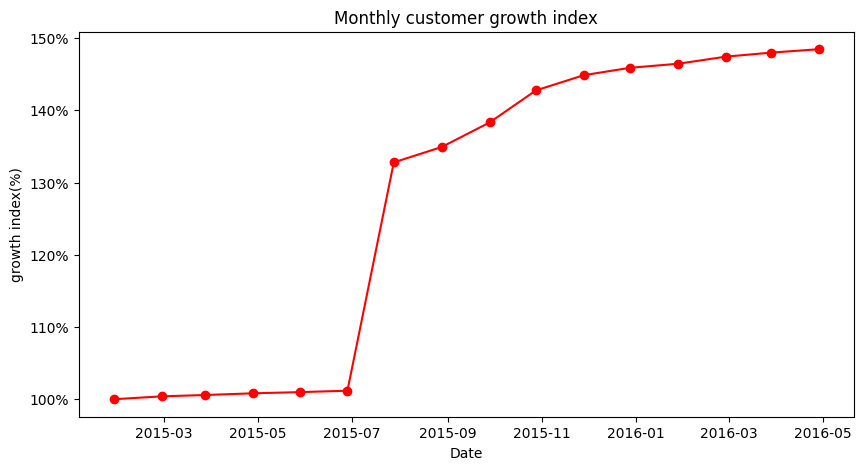

In [ ]:
# total customers
customer_per_month_train=(df_clean_train.groupby('date')['customer_id'].
                    nunique().reset_index().
                    rename(columns={'customer_id': 'n_customers'}))
#nunique(): number of unique values
plt.figure(figsize=(10, 5))
first_month_value=customer_per_month_train['n_customers'].iloc[0]
customer_per_month_train['growth_pct']=(customer_per_month_train['n_customers']/first_month_value)*100
plt.plot(customer_per_month_train['date'], customer_per_month_train['growth_pct'],
         marker='o', color='r', label='growth index')
plt.title('Monthly customer growth index')
plt.xlabel('Date')
plt.ylabel('growth index(%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
#make y-axis contain percentage values
plt.show()

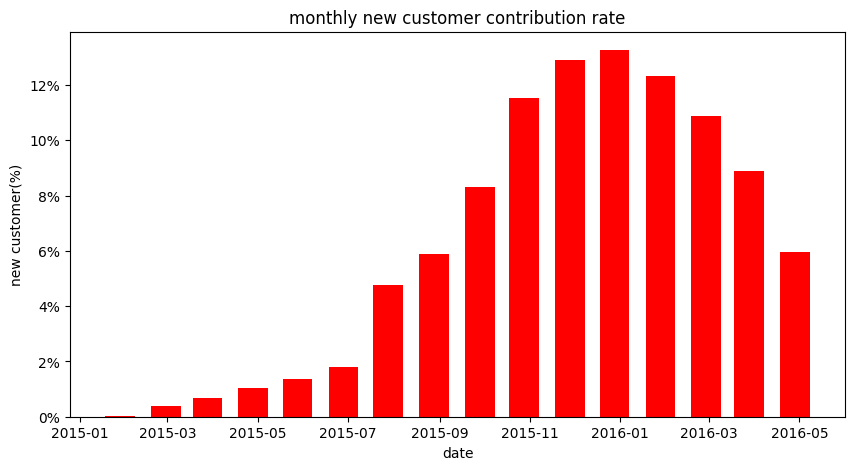

In [ ]:
import matplotlib.pyplot as plt
import importlib
importlib.reload(plt) # Reload matplotlib.pyplot to ensure plt.bar is the function
#new customers ***
new_per_month=(df_clean_train[df_clean_train['new_customer']==1].groupby('date')['customer_id'].
               nunique().reset_index().rename(columns={'customer_id':'n_new'}))
plt.figure(figsize=(10, 5))
total_new_all_time=new_per_month['n_new'].sum()
new_per_month['new_growth_pct']=(new_per_month['n_new']/total_new_all_time)*100
plt.bar(new_per_month['date'], new_per_month['new_growth_pct'], color='r',
        width=20, label='% of total new assets')
plt.title('monthly new customer contribution rate')
plt.xlabel('date')
plt.ylabel('new customer(%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.show()

the contribution rate sharply increases in a year from jan/2015, but witnesses a sharp fall from jan/2016 to may/2016

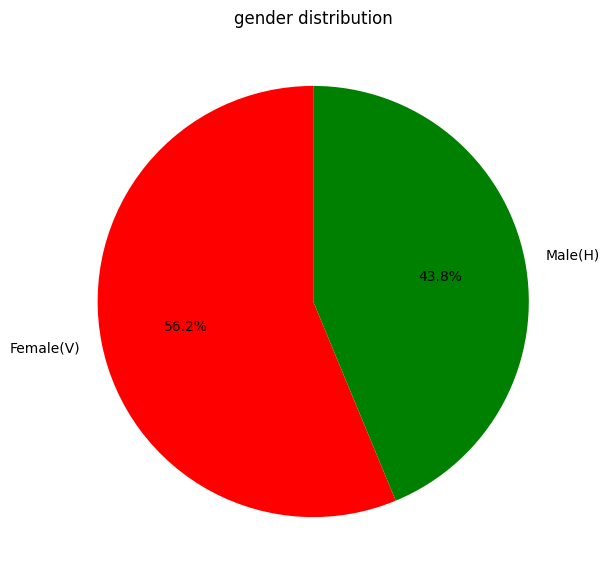

In [ ]:
#gender distribution
latest=(df_clean_train.sort_values('date').groupby('date').last().reset_index())
plt.figure(figsize=(7, 7))
gender_data=latest['gender'].value_counts(dropna=True)
plt.pie(gender_data.values, labels=['Female(V)', 'Male(H)'],
        autopct='%1.1f%%', colors=['r', 'g'], startangle=90)
plt.title('gender distribution')
plt.show()

distributing evenly between male and female

In [ ]:
df_clean_train['segment'].describe()

,segment
count,1253607
unique,3
top,02 - PARTICULARES
freq,741621


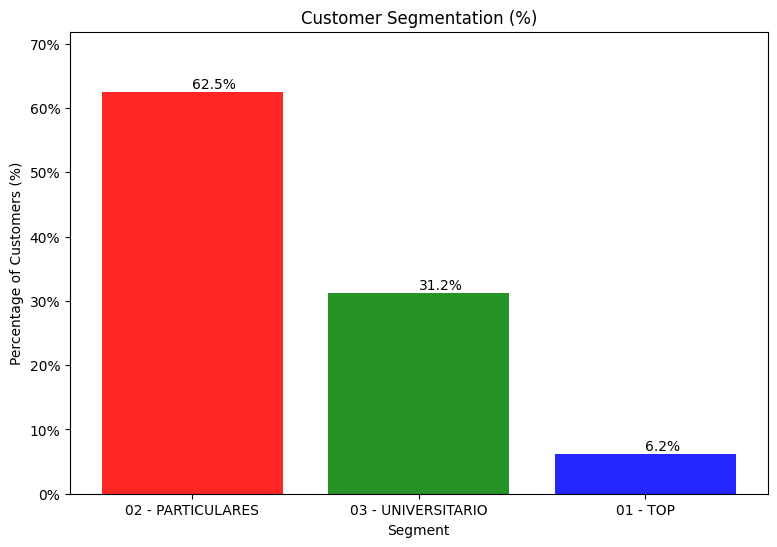

In [ ]:
# customer segmentation
plt.figure(figsize=(9, 6))
seg_perc = latest['segment'].value_counts(normalize=True).dropna() * 100
bars = plt.bar(seg_perc.index, seg_perc.values,
               color=['r', 'g', 'b'], alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval:.1f}%')
plt.title('Customer Segmentation (%)')
plt.xlabel('Segment')
plt.ylabel('Percentage of Customers (%)')
plt.ylim(0, max(seg_perc.values) * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.show()

In [ ]:
df_train['age'].describe()

,age
count,1.268792e+06
mean,4.021658e+01
std,1.708520e+01
min,1.800000e+01
25%,2.400000e+01
50%,3.900000e+01
75%,5.000000e+01
max,1.000000e+02


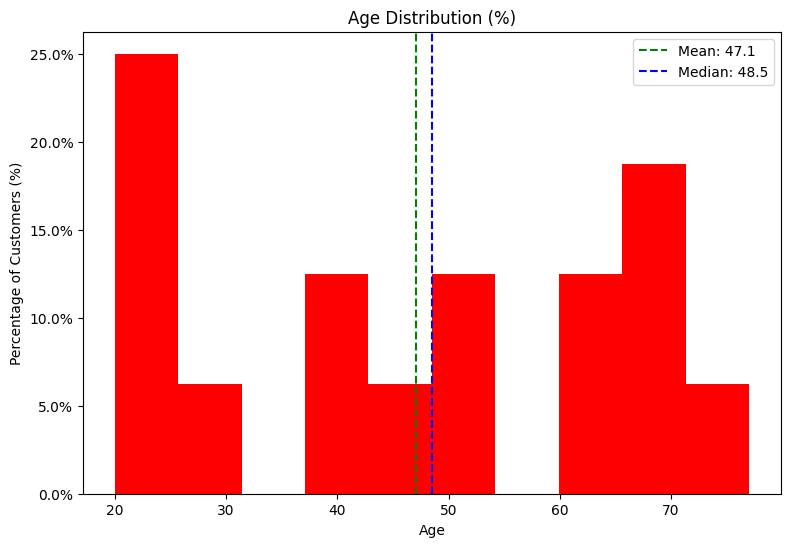

In [ ]:
import numpy as np
# age distribution
plt.figure(figsize=(9, 6))
age_data = latest['age'].dropna()
age_data = age_data[(age_data >= 18) & (age_data <= 100)]
weights = np.ones(len(age_data)) / len(age_data) * 100
plt.hist(age_data, bins=10, weights=weights, color='r')
plt.axvline(age_data.mean(), color='g', linestyle='--',
            label=f'Mean: {age_data.mean():.1f}')
plt.axvline(age_data.median(), color='b', linestyle='--',            label=f'Median: {age_data.median():.1f}')
plt.title('Age Distribution (%)')
plt.xlabel('Age')
plt.ylabel('Percentage of Customers (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.legend()
plt.show()

In [ ]:
df_train['income'].describe()

,income
count,1.015711e+06
mean,1.341049e+05
std,2.165519e+05
min,1.202730e+03
25%,6.870054e+04
50%,1.019178e+05
75%,1.560632e+05
max,2.889440e+07


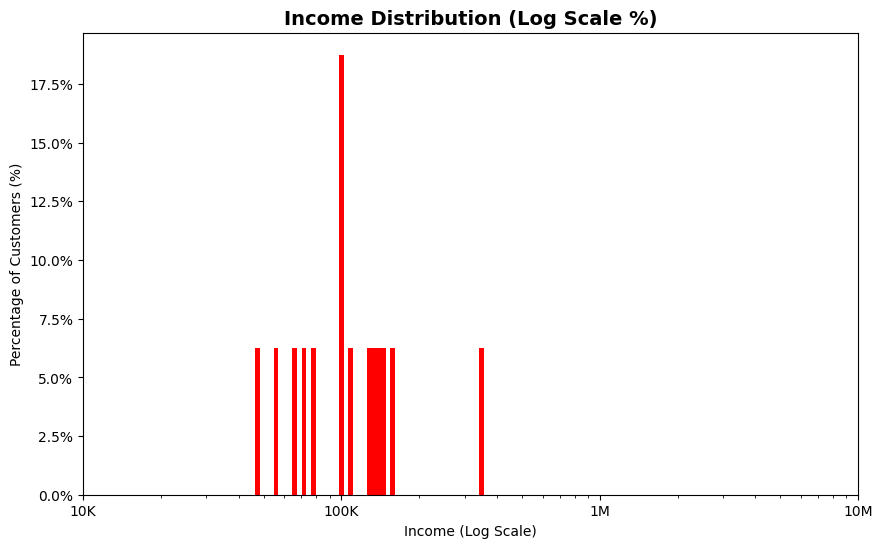

In [ ]:
# income distribution
plt.figure(figsize=(10, 6))
income_data = latest[latest['income'] > 0]['income'].dropna()
weights_inc = np.ones_like(income_data) / len(income_data) * 100
bins = np.logspace(np.log10(income_data.min()), np.log10(income_data.max()), 50)
plt.hist(income_data, bins=bins, weights=weights_inc, color='r')
plt.xscale('log')
plt.title('Income Distribution (Log Scale %)', fontsize=14, fontweight='bold')
plt.xlabel('Income (Log Scale)')
plt.ylabel('Percentage of Customers (%)')
plt.xticks([10**4, 10**5, 10**6, 10**7], ['10K', '100K', '1M', '10M'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.show()

In [ ]:
df_train['seniority'].describe()

,seniority
count,1.268792e+06
mean,7.934328e+01
std,6.632592e+01
min,0.000000e+00
25%,2.300000e+01
50%,5.000000e+01
75%,1.350000e+02
max,2.550000e+02


<Figure size 1000x600 with 0 Axes>

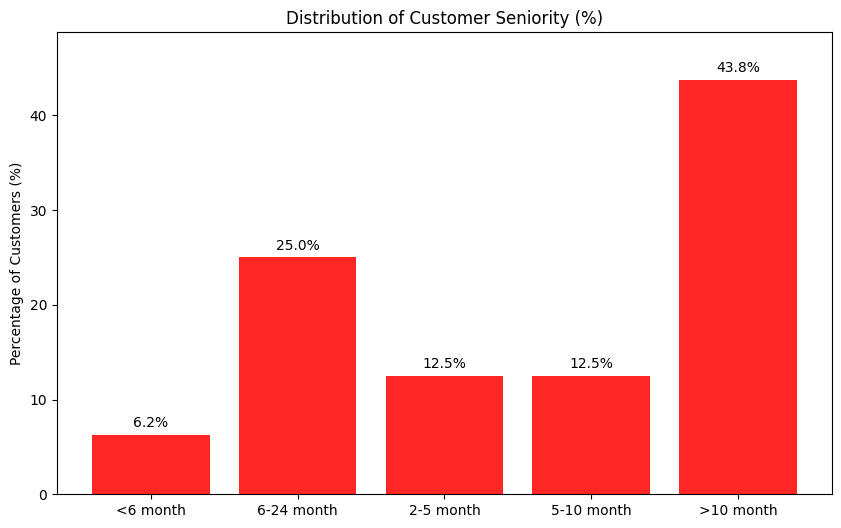

In [ ]:
# customer seniority distribution
bins   = [0, 6, 24, 60, 120, 999]
labels = ['<6 month', '6-24 month', '2-5 month', '5-10 month', '>10 month']
latest['seniority_group'] = pd.cut(latest['seniority'],
                                    bins=bins, labels=labels)
plt.figure(figsize=(10, 6))
sen_perc = latest['seniority_group'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(10, 6))
sen_perc = latest['seniority_group'].value_counts(normalize=True).sort_index() * 100
bars = plt.bar(sen_perc.index, sen_perc.values, color='r', alpha=0.85)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')
plt.title('Distribution of Customer Seniority (%)')
plt.ylabel('Percentage of Customers (%)')
plt.ylim(0, max(sen_perc.values) + 5)
plt.show()

customer seniority for more than 10 years takes the lead with 43.8%
more than 50% of customers for more than 5 years shows that the banks is good at customer management

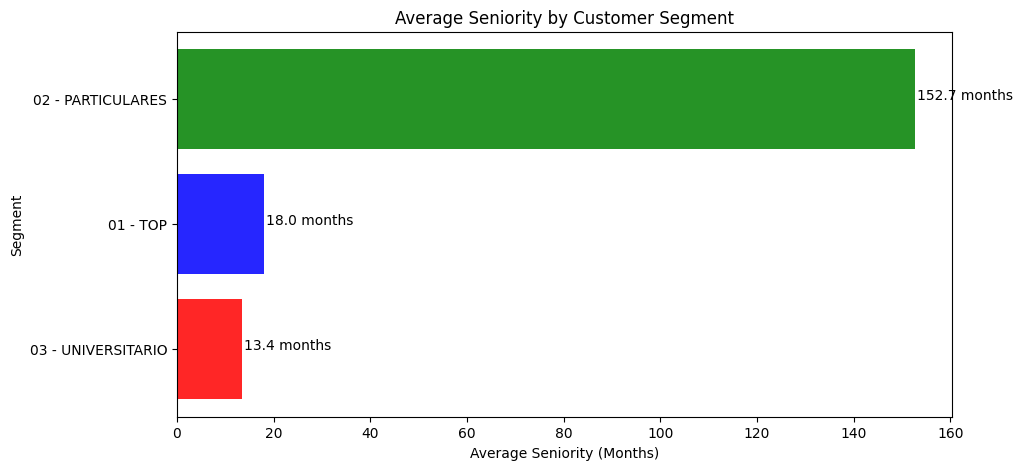

In [ ]:
# average seniority by customer
plt.figure(figsize=(10, 5))
sen_seg = (latest.groupby('segment', observed=True)['seniority']
           .mean().sort_values(ascending=True))
plt.barh(sen_seg.index, sen_seg.values,
         color=['r', 'b', 'g'], alpha=0.85)
for i, val in enumerate(sen_seg.values):
    plt.text(val + 0.5, i, f'{val:.1f} months')
plt.title('Average Seniority by Customer Segment')
plt.xlabel('Average Seniority (Months)')
plt.ylabel('Segment')
plt.show()

product analysis

In [ ]:
product_col_train=[]
for c in df_train.columns:
  if c.startswith('product_'):
    product_col_train.append(c)
product_names={
    'product_saving_account': 'saving account',
    'product_guarantees': 'guarantees',
    'product_current_account': 'current account',
    'product_Derivada_account': 'derivada account',
    'product_payroll_account': 'payroll account',
    'product_junior_account': 'junior account',
    'product_más_particular_account': 'more particular account',
    'product_particular_account': 'particular account',
    'product_particular+_account': 'particular+ account',
    'product_short_deposit': 'short deposit',
    'product_medium_deposit': 'medium deposit',
    'product_long_deposit': 'long deposit',
    'product_e_account': 'e account',
    'product_funds': 'funds',
    'product_mortgage': 'mortgage',
    'product_pensions_plan': 'pensions plan',
    'product_loans': 'loans',
    'product_taxes': 'taxes',
    'product_credit_card': 'credit card',
    'product_security': 'security',
    'product_home_account': 'home account',
    'product_payroll': 'payroll',
    'product_pensions': 'pensions',
    'product_direct_debit': 'direct debit'
}

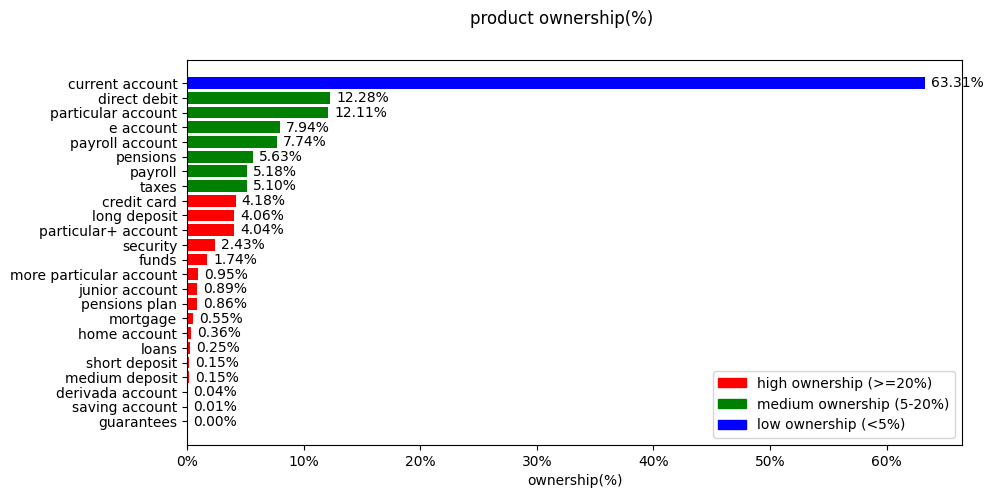

In [ ]:
#product ownership and data imbalance
latest=(df_clean_train.sort_values('date'). groupby('customer_id').last().reset_index())
ownership_pct=(latest[product_col_train].mean()*100).rename(product_names).sort_values(ascending=True)
fig, ax=plt.subplots(figsize=(10, 5))
fig.suptitle('product ownership(%)')
colors=[]
for v in ownership_pct.values:
  if v<5:
    colors.append('r')
  elif v<20:
    colors.append('g')
  else:
    colors.append('b')
bars=ax.barh(ownership_pct.index, ownership_pct.values, color=colors)
for bar, val in zip(bars, ownership_pct.values):
#zip(bars, ownership_pct.values): (bar, ownership_pct)
  ax.text(bar.get_width()+0.5,
          bar.get_y()+bar.get_height()/2,
          f'{val:.2f}%',
          va='center')
ax.set_xlabel('ownership(%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color='r', label='high ownership (>=20%)'),
    plt.Rectangle((0, 0), 1, 1, color='g', label='medium ownership (5-20%)'),
    plt.Rectangle((0, 0), 1, 1, color='b', label='low ownership (<5%)')
], loc='lower right')
plt.savefig('product_analysis_combined.png', dpi=150, bbox_inches='tight')
#plt.savefig(): save the figure in form of image
plt.show()

current account takes the lead with 63.31%, while saving account and guarantees reach almost at 0%

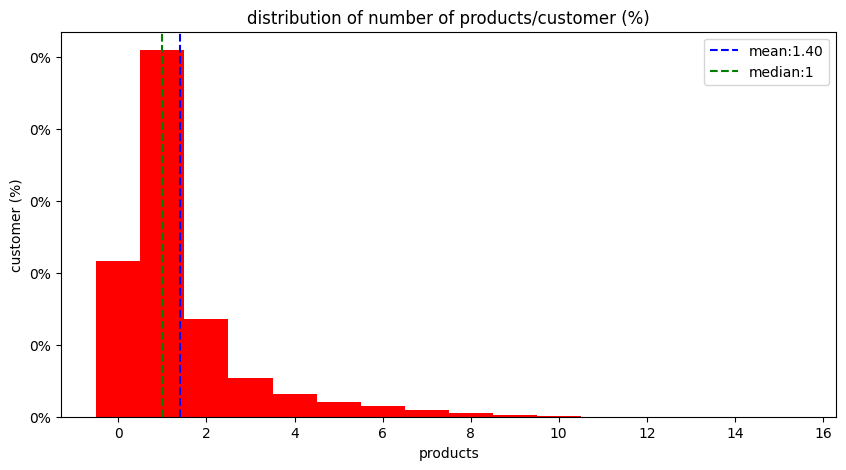

In [ ]:
#product/customer
plt.figure(figsize=(10, 5))
latest['n_products']=latest[product_col_train].sum(axis=1)
weights=np.ones_like(latest['n_products'])/len(latest['n_products']*100)
#an element of column n_product/number of elements of column n+product *100
plt.hist(latest['n_products'], bins=range(0, latest['n_products'].max()+2),
         weights=weights, color='r', align='left')
plt.axvline(latest['n_products'].mean(), color='b', linestyle='--',
            label=f"mean:{latest['n_products'].mean():.2f}")
plt.axvline(latest['n_products'].median(), color='g', linestyle='--',
            label=f"median:{latest['n_products'].median():.0f}")
plt.title('distribution of number of products/customer (%)')
plt.xlabel('products')
plt.ylabel('customer (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.legend()
plt.show()

most customers posess from 1 to 2 products

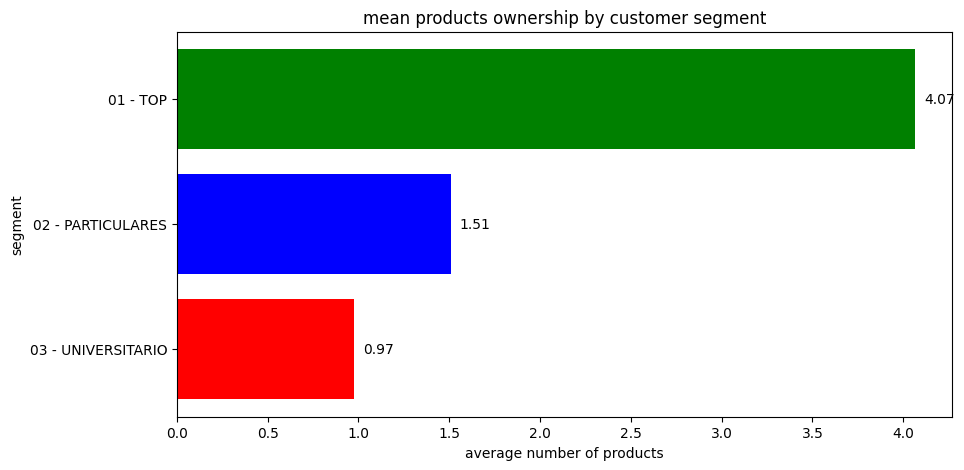

In [ ]:
#mean(products) by segment
plt.figure(figsize=(10, 5))
seg_prod=(latest.groupby('segment', observed=True)['n_products']
          .mean().sort_values(ascending=True))
bars=plt.barh(seg_prod.index, seg_prod.values, color=['r', 'b', 'g'])
for bar, val in zip(bars, seg_prod.values):
  plt.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
           f'{val:.2f}', va='center')
plt.title('mean products ownership by customer segment')
plt.xlabel('average number of products')
plt.ylabel('segment')
plt.show()

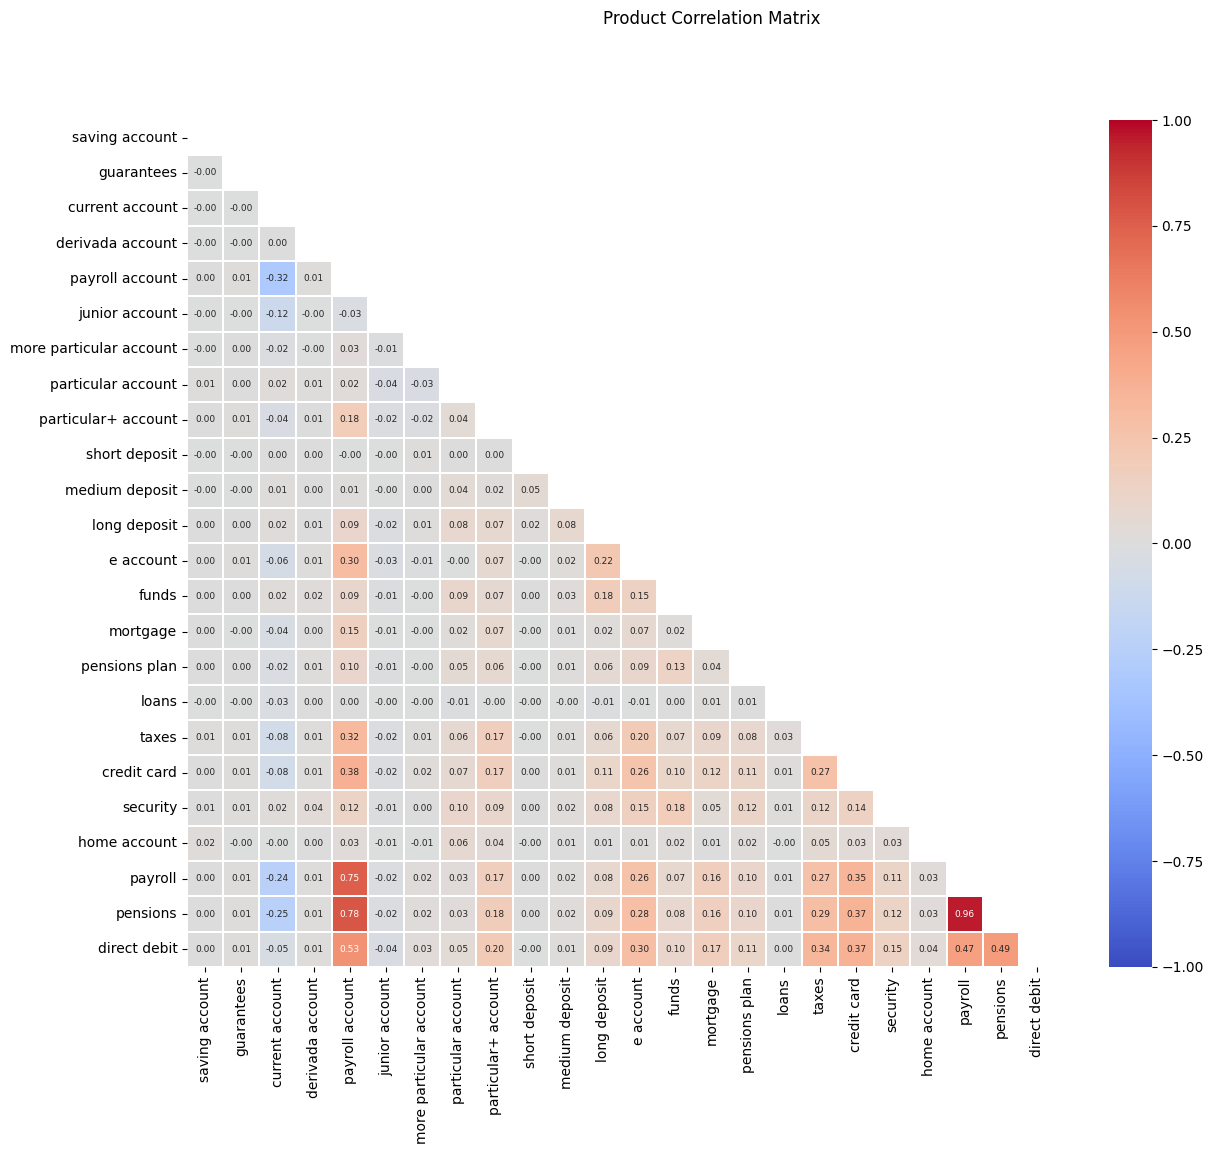

In [ ]:
# product correlation
corr_matrix = latest[product_col_train].corr()
corr_matrix.index   = [product_names[c] for c in product_col_train]
corr_matrix.columns = [product_names[c] for c in product_col_train]
fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Product Correlation Matrix')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 6.5}, ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.savefig('phase4_4.png', dpi=150, bbox_inches='tight')
plt.show()

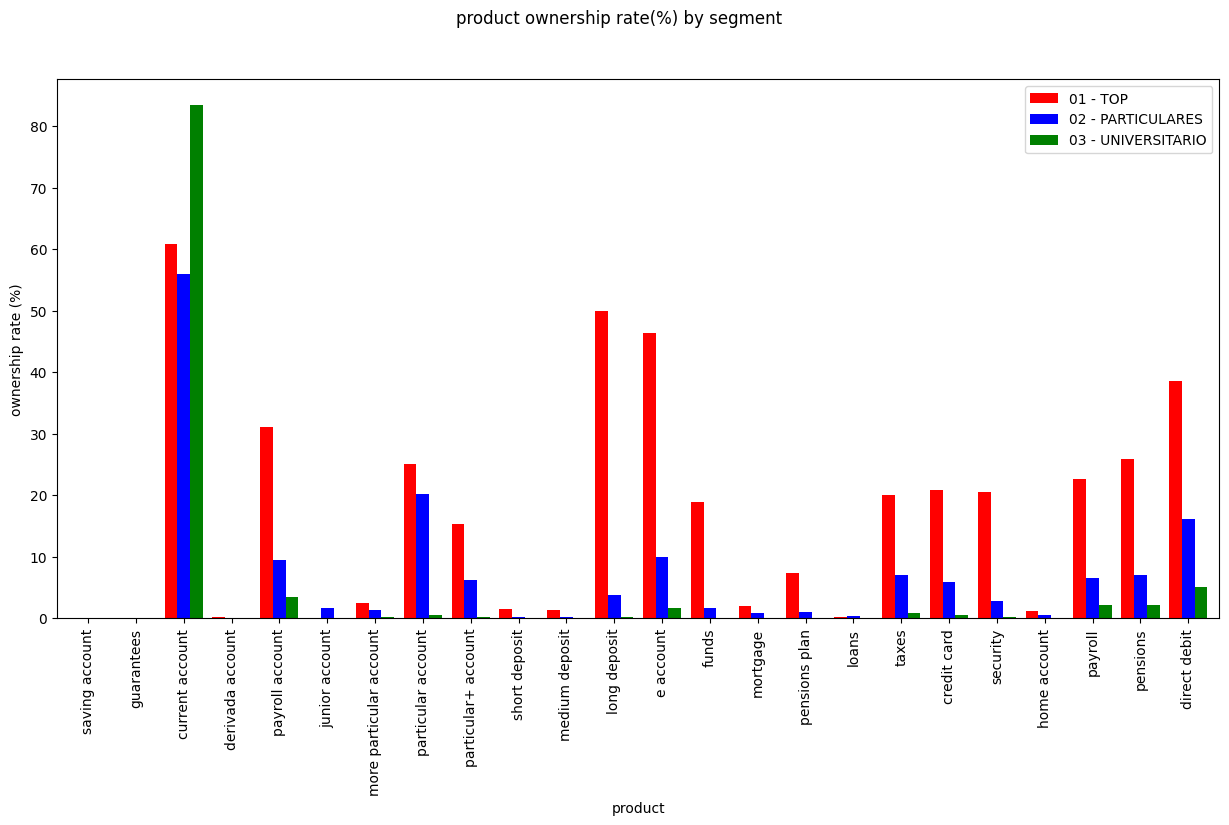

In [ ]:
#product ownership rate(%) by segment
seg_product=(df_clean_train.groupby('segment', observed=True)[product_col_train].mean()*100)
seg_product.columns=[product_names[c]for c in product_col_train]
fig, ax=plt.subplots(figsize=(15, 7))
fig.suptitle('product ownership rate(%) by segment')
seg_product.T.plot(kind='bar', ax=ax, color=['r', 'b', 'g'], width=0.8)
#create a bar chart from segment product
ax.set_xlabel('product')
ax.set_ylabel('ownership rate (%)')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper right')
plt.savefig('phase4_5.png', dpi=50, bbox_inches='tight')
plt.show()

Temporal analysis

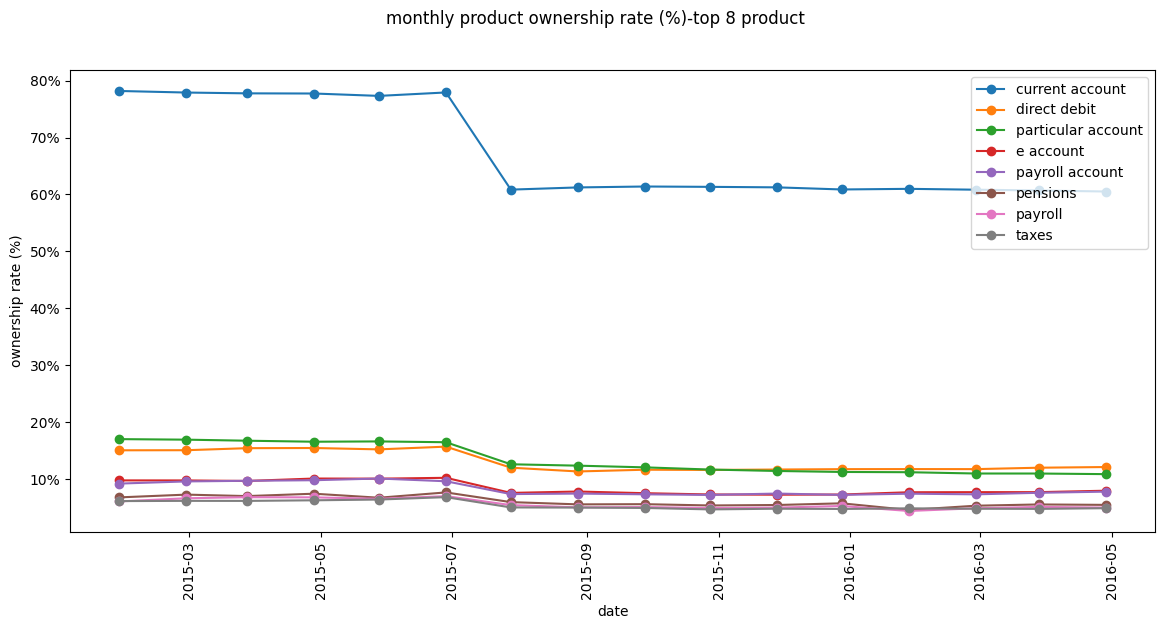

In [ ]:
#monthly product ownership
monthly_product=(df_clean_train.groupby('date')[product_col_train].mean()*100)
monthly_product.columns=[product_names[c] for c in product_col_train]
top8=(latest[product_col_train].mean().rename(product_names).
      sort_values(ascending=False). head(8). index.tolist())
#a list of top 8 products that customers own the most
fig, ax=plt.subplots(figsize=(14, 6))
fig.suptitle('monthly product ownership rate (%)-top 8 product')
for product in top8:
  ax.plot(monthly_product.index, monthly_product[product], marker='o', label=product)
ax.set_xlabel('date')
ax.set_ylabel('ownership rate (%)')
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.savefig('phase4_6.png', dpi=50, bbox_inches='tight')
plt.show()

there is a decrease at jul/2015

<Figure size 1000x500 with 0 Axes>

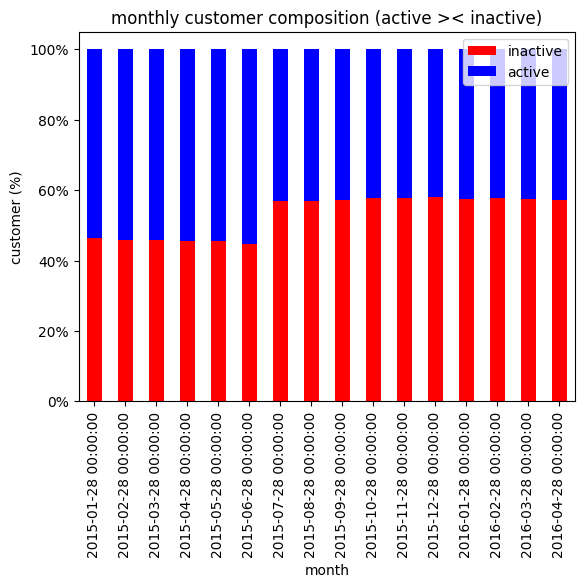

In [ ]:
#monthly customer composition (active vs inactive)
active_monthly=(df_clean_train.groupby(['date', 'active_customer']).size().
                unstack(fill_value=0).rename(columns={0.0: 'inactive', 1.0:'active'}))
#size(): counting rows inside each group
#unstack(fill_value=0): convert active_customer into columns
#fill_value=0: if value is NaN, turn them to 0
#rename(columns={0.0: 'inactive', 1.0:'active'}): rename column 0 as inactive and column 1 as active
active_pct=active_monthly.div(active_monthly.sum(axis=1), axis=0)*100
#active_monthly.sum(axis=1): sum each row
#active_monthly.div(active_monthly.sum(axis=1), axis=0): divide this row with corresponding row total
plt.figure(figsize=(10, 5))
ax1=active_pct.plot(kind='bar', stacked=True, color=['r','b'])
plt.title('monthly customer composition (active >< inactive)')
plt.xlabel('month')
plt.ylabel('customer (%)')
plt.xticks(rotation=90)
plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.savefig('phase5_2a.png', dpi=150, bbox_inches='tight')
plt.show()
#

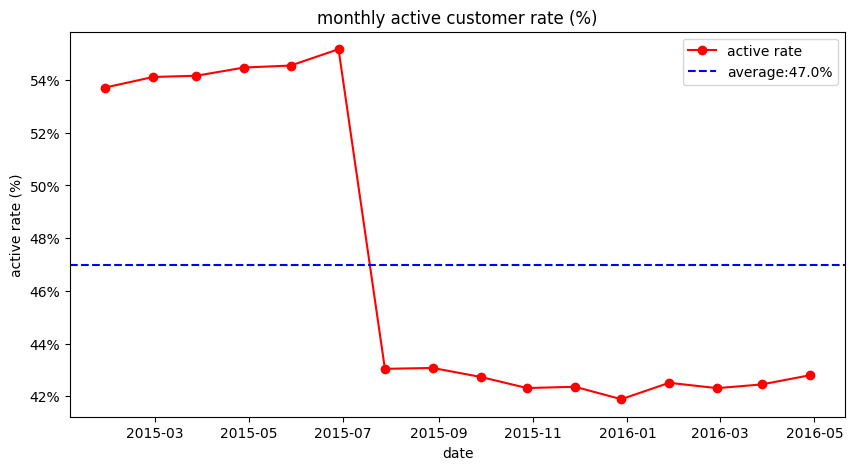

In [ ]:
#monthly active customer rate
active_rate=(active_monthly['active']/
             (active_monthly['active']+active_monthly['inactive'])*100)
plt.figure(figsize=(10, 5))
plt.plot(active_rate.index, active_rate.values, marker='o', color='r',
         label='active rate')
avg_rate=active_rate.mean()
plt.axhline(avg_rate, color='b', linestyle='--', label=f'average:{avg_rate:.1f}%')
plt.title('monthly active customer rate (%)')
plt.xlabel('date')
plt.ylabel('active rate (%)')
plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.savefig('phase5_2b.png', dpi=150, bbox_inches='tight')
plt.show()

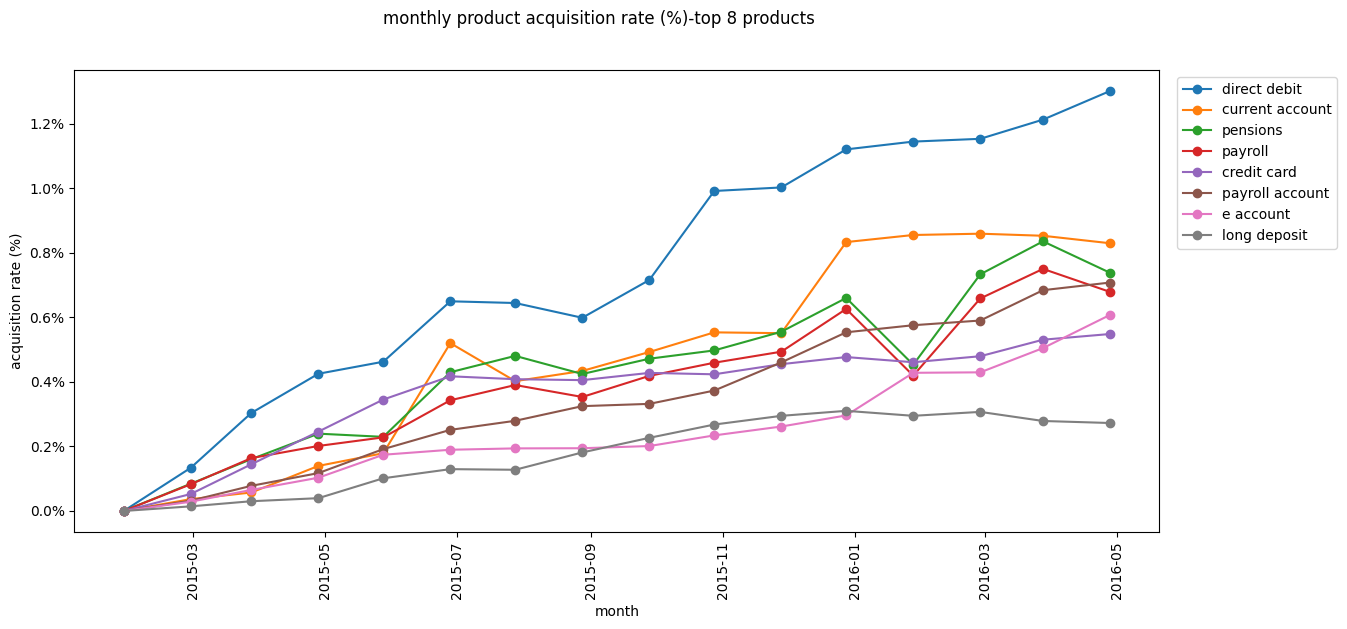

In [ ]:
#product acquisition trend
df_sorted=df_clean_train.sort_values(['customer_id', 'date'])
product_diffs=df_sorted.groupby('customer_id')[product_col_train].diff()
#diff()=current value - previous value
acquisitions=(product_diffs==1).astype(int)
acquisitions['date']=df_sorted['date']
monthly_acquisitions=acquisitions.groupby('date').sum()
monthly_customer_count=df_clean_train.groupby('date').size()
monthly_acquisitions_rate=monthly_acquisitions.div(monthly_customer_count,
                                                   axis=0)*100
monthly_acquisitions_rate.columns=[product_names[c] for c in product_col_train]
top8_added=monthly_acquisitions_rate.mean().sort_values(ascending=False).head(8).index.tolist()
fig, ax=plt.subplots(figsize=(14, 6))
fig.suptitle('monthly product acquisition rate (%)-top 8 products')
for product in top8_added:
  ax.plot(monthly_acquisitions_rate.index, monthly_acquisitions_rate[product],
          marker='o', label=product)
ax.set_xlabel('month')
ax.set_ylabel('acquisition rate (%)')
ax.legend(bbox_to_anchor=(1.01, 1),loc='upper left')
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.savefig('phase5_3.png', dpi=150, bbox_inches='tight')
plt.show()

recommendation-oriented analysis

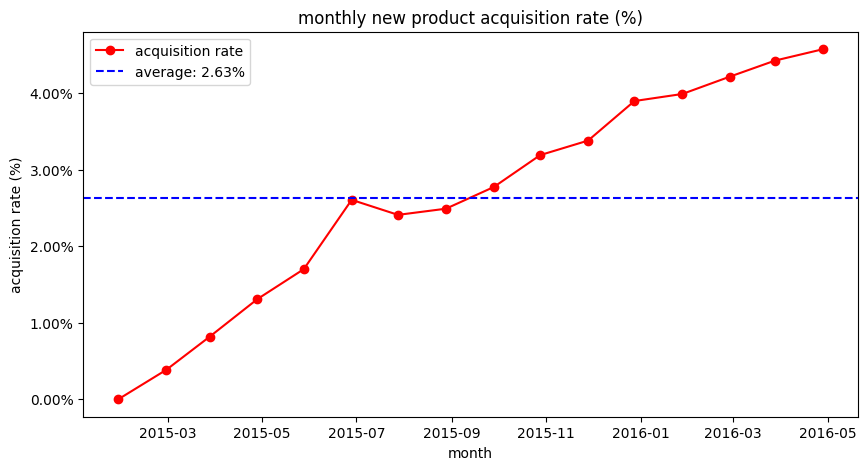

In [ ]:
#monthly new product acquisition rate
product_diffs=df_sorted.groupby('customer_id')[product_col_train].diff()
df_sorted['added_any']=(product_diffs==1).any(axis=1).astype(int)
#any(axis=1): check value=1
purchase_stats=df_sorted.groupby('date')['added_any'].agg(['sum', 'count']).reset_index()
purchase_stats['purchase_rate']=purchase_stats['sum']/purchase_stats['count']*100
purchase_stats['no_change_rate']=100-purchase_stats['purchase_rate']
plt.figure(figsize=(10, 5))
plt.plot(purchase_stats['date'], purchase_stats['purchase_rate'], marker='o', color='r', label='acquisition rate')
avg_purchase_rate=purchase_stats['purchase_rate'].mean()
plt.axhline(avg_purchase_rate, color='b', linestyle='--',
            label=f'average: {avg_purchase_rate:.2f}%')
plt.title('monthly new product acquisition rate (%)')
plt.xlabel('month')
plt.ylabel('acquisition rate (%)')
plt.legend(loc='upper left')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}%'))
plt.savefig('phase6_1b.png', dpi=150, bbox_inches='tight')
plt.show()

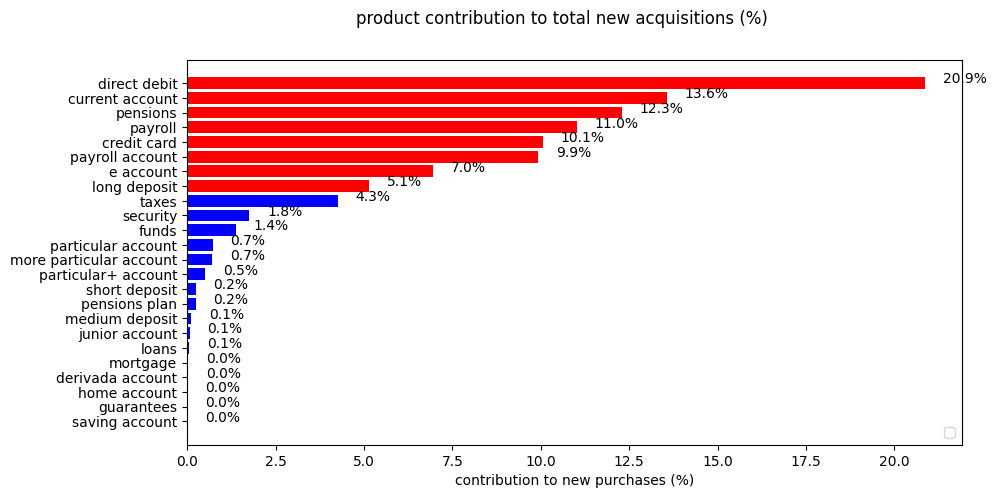

In [ ]:
#product by new acquisition
df_sorted=df_clean_train.sort_values(['customer_id', 'date'])
product_diffs=df_sorted.groupby('customer_id')[product_col_train].diff()
total_new_counts=(product_diffs==1).sum()
total_new_counts.index=[product_names[c]for c in product_col_train]
total_new_counts=total_new_counts.sort_values(ascending=True)
total_acquisitions=total_new_counts.sum()
contribution_rate=total_new_counts/total_acquisitions *100
fig, ax=plt.subplots(figsize=(10, 5))
fig.suptitle('product contribution to total new acquisitions (%)')
colors=['r' if v>5 else 'b' for v in contribution_rate.values]
bars=ax.barh(contribution_rate.index, contribution_rate.values, color=colors)
for bar, val in zip(bars, contribution_rate.values):
  ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,f'{val:.1f}%')
ax.set_xlabel('contribution to new purchases (%)')
ax.legend(loc='lower right')
plt.savefig('phase6_2.png', dpi=150, bbox_inches='tight')
plt.show()

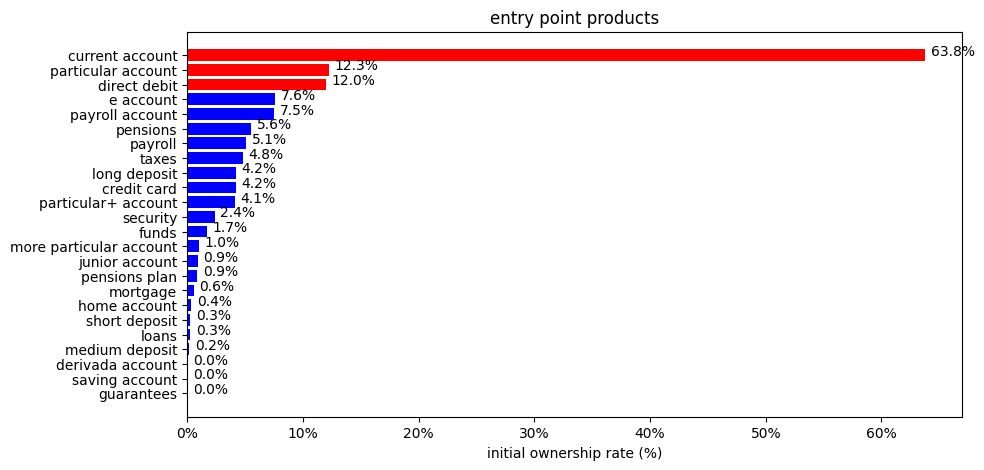

In [ ]:
#customer first product
first_month=df_sorted.groupby('customer_id').first()
first_products=first_month[product_col_train].sum().rename(product_names)
first_products_rate=first_products/len(first_month) *100
first_products_rate=first_products_rate.sort_values(ascending=True)
plt.figure(figsize=(10,5))
colors=['r' if v>10 else 'b' for v in first_products_rate.values]
bars=plt.barh(first_products_rate.index, first_products_rate.values, color=colors)
for bar, val in zip(bars, first_products_rate.values):
  plt.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%')
plt.title('entry point products')
plt.xlabel('initial ownership rate (%)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.savefig('phase 6_3a.png', dpi=150, bbox_inches='tight')
plt.show()

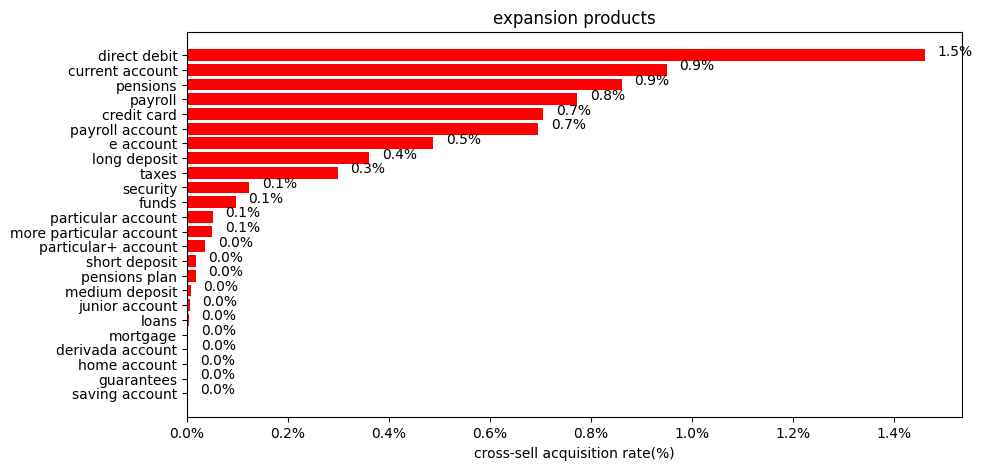

In [ ]:
#customer next product
expansion_rate=total_new_counts/len(df_clean_train['customer_id'].unique())*100
expansion_rate=expansion_rate.sort_values(ascending=True)
plt.figure(figsize=(10, 5))
colors=['b' if v>2 else 'r' for v in expansion_rate.values]
bars=plt.barh(expansion_rate.index, expansion_rate.values, color=colors)
for bar, val in zip(bars, expansion_rate.values):
  plt.text(bar.get_width()+0.025, bar.get_y()+bar.get_height()/2, f'{val:.1f}%')
plt.title('expansion products')
plt.xlabel('cross-sell acquisition rate(%)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.savefig('phase6_3b.png', dpi=150, bbox_inches='tight')

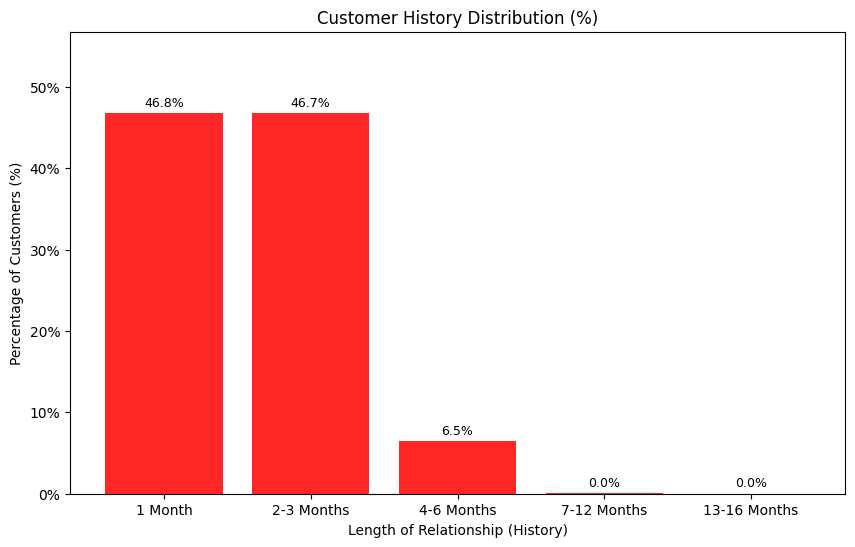

In [ ]:
# customer history distribution
history_len = df_sorted.groupby('customer_id')['date'].nunique().reset_index(name='n_months')
bins = [0, 1, 3, 6, 12, 16]
labels = ['1 Month', '2-3 Months', '4-6 Months', '7-12 Months', '13-16 Months']
history_len['history_group'] = pd.cut(history_len['n_months'], bins=bins, labels=labels)
hist_dist = history_len['history_group'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(10, 6))
bars = plt.bar(hist_dist.index, hist_dist.values, color='r', alpha=0.85)
for bar, val in zip(bars, hist_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Customer History Distribution (%)')
plt.xlabel('Length of Relationship (History)')
plt.ylabel('Percentage of Customers (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.ylim(0, max(hist_dist.values) + 10)
plt.savefig('phase6_4a_coldstart_dist.png', dpi=150)
plt.show()

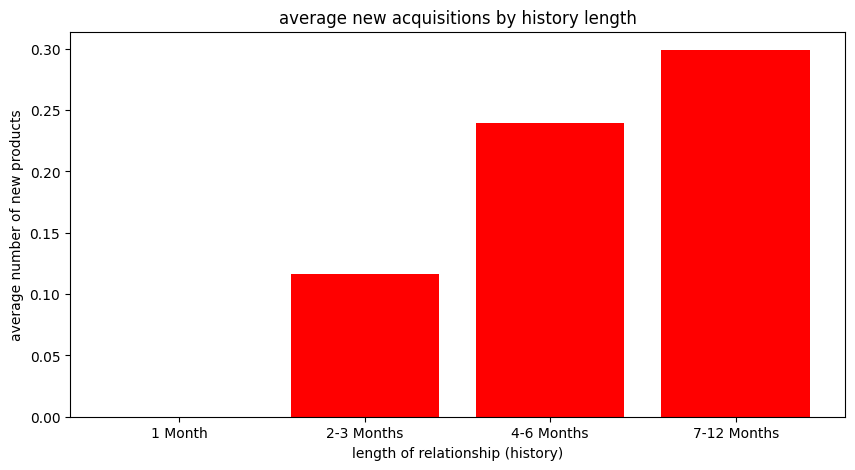

In [ ]:
#new product/history
customer_purchases=(product_diffs==1).sum(axis=1).groupby(df_sorted['customer_id']).sum().reset_index(name='total_acquisitions')

cold_start_df=history_len.merge(customer_purchases, on='customer_id')
avg_acquisitions=cold_start_df.groupby('history_group', observed=True)['total_acquisitions'].mean()
plt.figure(figsize=(10, 5))
plt.bar=plt.bar(avg_acquisitions.index, avg_acquisitions.values, color='r')
plt.title('average new acquisitions by history length')
plt.xlabel('length of relationship (history)')
plt.ylabel('average number of new products')
plt.savefig('phase6_4b.png', dpi=150, bbox_inches='tight')
plt.show()

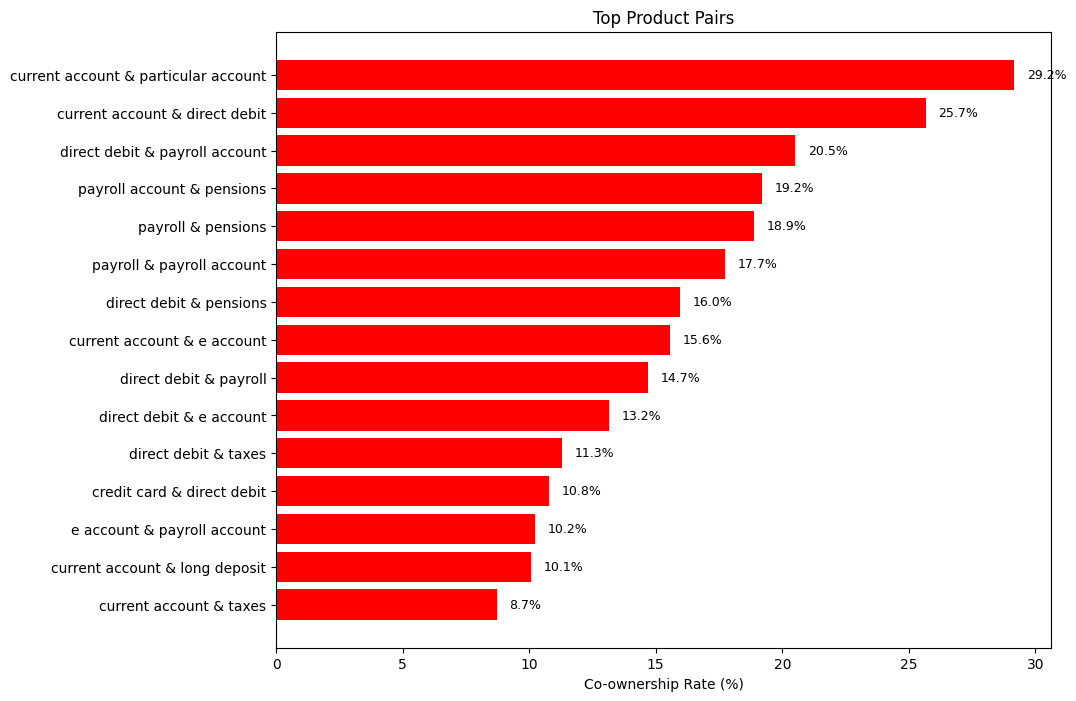

In [ ]:
# top pair
from itertools import combinations
multi_product = latest[latest[product_col_train].sum(axis=1) >= 2]
pair_counts = {}
for _, row in multi_product[product_col_train].iterrows():
    owned = [c for c in product_col_train if row[c] == 1]
    for a, b in combinations(owned, 2):
        key = tuple(sorted([product_names[a], product_names[b]]))
        pair_counts[key] = pair_counts.get(key, 0) + 1
pairs_df = (pd.DataFrame.from_dict(pair_counts, orient='index', columns=['count'])
              .reset_index()
              .rename(columns={'index': 'pair'}))
pairs_df['product_a'] = pairs_df['pair'].apply(lambda x: x[0])
pairs_df['product_b'] = pairs_df['pair'].apply(lambda x: x[1])
pairs_df = pairs_df.sort_values('count', ascending=False).head(15)
pairs_df['pair_label'] = pairs_df['product_a'] + ' & ' + pairs_df['product_b']
pairs_df['pct'] = (pairs_df['count'] / len(multi_product)) * 100
plt.figure(figsize=(10, 8))
bars = plt.barh(pairs_df['pair_label'], pairs_df['pct'], color='r')
for bar, val in zip(bars, pairs_df['pct']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.title('Top Product Pairs')
plt.xlabel('Co-ownership Rate (%)')
plt.gca().invert_yaxis()
plt.savefig('phase6_5a_product_pairs.png', dpi=150)
plt.show()

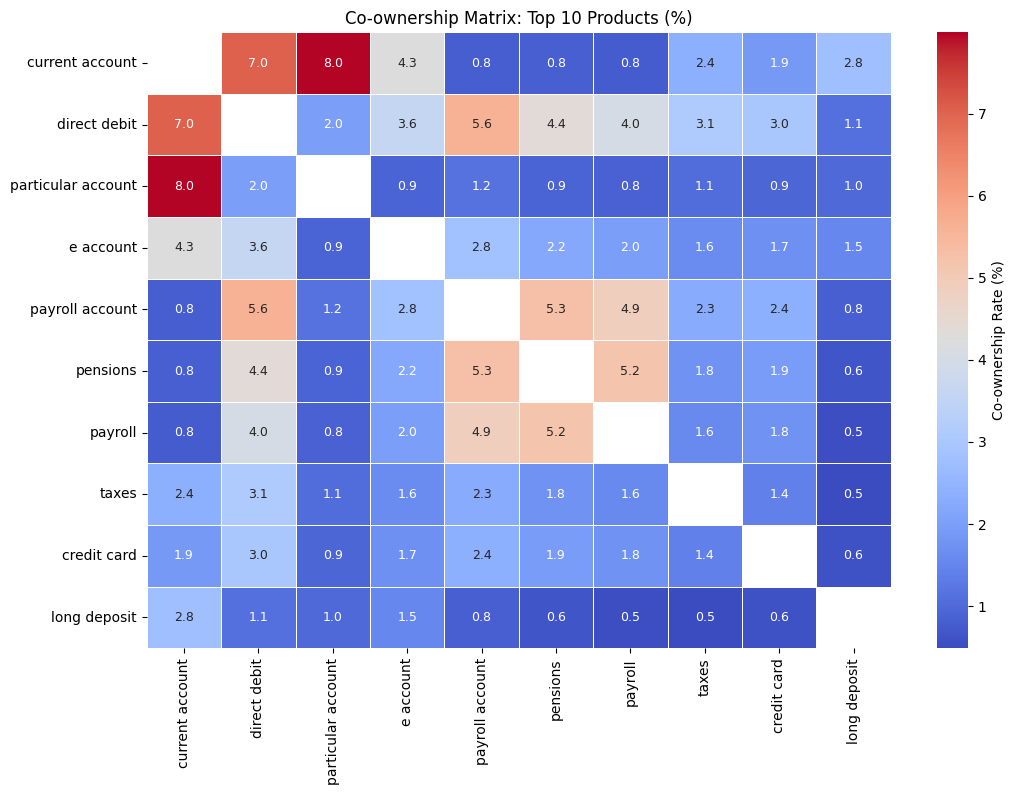

In [ ]:
# co-ownership matrix
top10_prods = latest[product_col_train].mean().sort_values(ascending=False).head(10).index.tolist()
co_matrix = pd.DataFrame(0, index=top10_prods, columns=top10_prods)
n_customers = len(latest)
for p1 in top10_prods:
    for p2 in top10_prods:
        if p1 != p2:
            co_matrix.loc[p1, p2] = ((latest[p1] == 1) & (latest[p2] == 1)).sum() / n_customers * 100
co_matrix.index   = [product_names[c] for c in top10_prods]
co_matrix.columns = [product_names[c] for c in top10_prods]
mask_diag = np.eye(len(co_matrix), dtype=bool)
plt.figure(figsize=(12, 8))
sns.heatmap(co_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            mask=mask_diag, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Co-ownership Rate (%)'})
plt.title('Co-ownership Matrix: Top 10 Products (%)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('phase6_5b_co_matrix.png', dpi=150)
plt.show()

Other

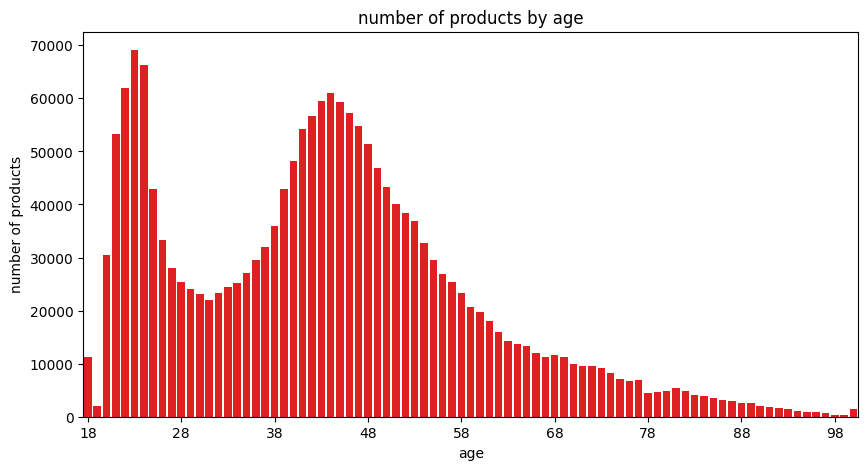

 age  tot_products
23.0         69104
24.0         66250
22.0         62019
44.0         60989
43.0         59452
45.0         59355
46.0         57282
42.0         56652
47.0         54753
41.0         54213


In [ ]:
#number of products by age
df_clean_train['tot_products']=df_clean_train[product_col_train].sum(axis=1)
df_age_dist=df_clean_train.groupby('age')['tot_products'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_age_dist, x='age', y='tot_products', color='r')
plt.xticks(np.arange(0, 85, 10), [int(x+18) for x in np.arange(0, 85, 10)])
#changes x-axis tick positions and labels
plt.title('number of products by age')
plt.xlabel('age')
plt.ylabel('number of products')
plt.show()
print(df_age_dist.sort_values(by='tot_products', ascending=False).head(10).to_string(index=False))

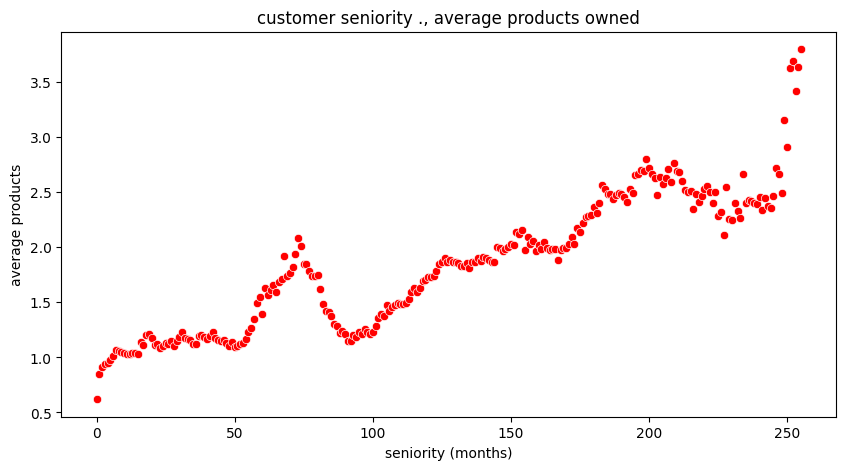

In [ ]:
#customer seniority >< average products owned
df_trend=df_clean_train.groupby('seniority')['tot_products'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_trend, x='seniority', y='tot_products', color='r')
plt.title('customer seniority ., average products owned')
plt.xlabel('seniority (months)')
plt.ylabel('average products')
plt.show()

In [ ]:
data_test=r"/content/drive/MyDrive/test.csv"
chunk_size=200000
sample_rate=0.10
chunks=[]
for chunk in pd.read_csv(data_test, chunksize=chunk_size, low_memory=False):
  df=chunk.sample(frac=sample_rate, random_state=42)
  chunks.append(df)
df_test=pd.concat(chunks, ignore_index=True)
print(df_test.head())
print(df_test.info())

   fecha_dato  ncodpers ind_empleado pais_residencia sexo  age  fecha_alta  \
0  2016-05-28    921682            N              ES    V   25  2011-07-27   
1  2016-05-28    531130            N              ES    H   48  2005-04-29   
2  2016-05-28    958941            N              ES    H   35  2011-10-11   
3  2016-05-28    517569            N              ES    H   67  2005-02-14   
4  2016-05-28    722258            N              ES    V   67  2007-10-01   

   ind_nuevo  antiguedad  indrel  ... ind_hip_fin_ult1 ind_plan_fin_ult1  \
0        0.0          58     1.0  ...                0                 0   
1        0.0         133     1.0  ...                0                 0   
2        0.0          55     1.0  ...                0                 0   
3        0.0         135     1.0  ...                0                 0   
4        0.0         103     1.0  ...                0                 0   

  ind_pres_fin_ult1 ind_reca_fin_ult1 ind_tjcr_fin_ult1 ind_valo_fin_ult1 

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha_dato             93145 non-null  object 
 1   ncodpers               93145 non-null  int64  
 2   ind_empleado           93145 non-null  object 
 3   pais_residencia        93145 non-null  object 
 4   sexo                   93145 non-null  object 
 5   age                    93145 non-null  int64  
 6   fecha_alta             93145 non-null  object 
 7   ind_nuevo              93145 non-null  float64
 8   antiguedad             93145 non-null  int64  
 9   indrel                 93145 non-null  float64
 10  ult_fec_cli_1t         177 non-null    object 
 11  indrel_1mes            92783 non-null  object 
 12  tiprel_1mes            92783 non-null  object 
 13  indresi                93145 non-null  object 
 14  indext                 93145 non-null  object 
 15  co

In [ ]:
df_test.rename(columns={
    'fecha_dato': 'date',
    'ncodpers': 'customer_id',
    'ind_empleado': 'employee_index',
    'pais_residencia': 'country',
    'sexo': 'gender',
    'age' : 'age',
    'fecha_alta': 'join_date',
    'ind_nuevo': 'new_customer',
    'antiguedad': 'seniority',
    'indrel': 'customer_type',
    'ult_fec_cli_1t': 'last_primary_date',
    'indrel_1mes': 'customer_relation_month_start',
    'tiprel_1mes': 'relation_type',
    'indresi': 'resident',
    'indext': 'foreigner',
    'conyuemp': 'employee_spouse',
    'canal_entrada': 'join_channel',
    'indfall': 'deceased',
    'tipodom': 'address_type',
    'cod_prov': 'province_code',
    'nomprov': 'provience',
    'ind_actividad_cliente': 'active_customer',
    'renta': 'income',
    'segmento': 'segment',
    'ind_ahor_fin_ult1': 'product_saving_account',
    'ind_aval_fin_ult1': 'product_guarantees',
    'ind_cco_fin_ult1': 'product_current_account',
    'ind_cder_fin_ult1': 'product_Derivada_account',
    'ind_cno_fin_ult1': 'product_payroll_account',
    'ind_ctju_fin_ult1': 'product_junior_account',
    'ind_ctma_fin_ult1': 'product_más_particular_account',
    'ind_ctop_fin_ult1': 'product_particular_account',
    'ind_ctpp_fin_ult1': 'product_particular+_account',
    'ind_deco_fin_ult1': 'product_short_deposit',
    'ind_deme_fin_ult1': 'product_medium_deposit',
    'ind_dela_fin_ult1': 'product_long_deposit',
    'ind_ecue_fin_ult1': 'product_e_account',
    'ind_fond_fin_ult1': 'product_funds',
    'ind_hip_fin_ult1': 'product_mortgage',
    'ind_plan_fin_ult1': 'product_pensions_plan',
    'ind_pres_fin_ult1': 'product_loans',
    'ind_reca_fin_ult1': 'product_taxes',
    'ind_tjcr_fin_ult1': 'product_credit_card',
    'ind_valo_fin_ult1': 'product_security',
    'ind_viv_fin_ult1': 'product_home_account',
    'ind_nomina_ult1': 'product_payroll',
    'ind_nom_pens_ult1': 'product_pensions',
    'ind_recibo_ult1': 'product_direct_debit'
}, inplace=True)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   date                            93145 non-null  object 
 1   customer_id                     93145 non-null  int64  
 2   employee_index                  93145 non-null  object 
 3   country                         93145 non-null  object 
 4   gender                          93145 non-null  object 
 5   age                             93145 non-null  int64  
 6   join_date                       93145 non-null  object 
 7   new_customer                    93145 non-null  float64
 8   seniority                       93145 non-null  int64  
 9   customer_type                   93145 non-null  float64
 10  last_primary_date               177 non-null    object 
 11  customer_relation_month_start   92783 non-null  object 
 12  relation_type                   

In [ ]:
product_col_test=[]
for c in df_test.columns:
  if c.startswith('product_'):
    product_col_test.append(c)
print(product_col_test)

['product_saving_account', 'product_guarantees', 'product_current_account', 'product_Derivada_account', 'product_payroll_account', 'product_junior_account', 'product_más_particular_account', 'product_particular_account', 'product_particular+_account', 'product_short_deposit', 'product_medium_deposit', 'product_long_deposit', 'product_e_account', 'product_funds', 'product_mortgage', 'product_pensions_plan', 'product_loans', 'product_taxes', 'product_credit_card', 'product_security', 'product_home_account', 'product_payroll', 'product_pensions', 'product_direct_debit']


In [ ]:
df_test[product_col_test]=df_test[product_col_test].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int8')
df_test['age']=pd.to_numeric(df_test['age'], errors='coerce').astype('float32')
df_test['income']=pd.to_numeric(df_test['income'], errors='coerce').astype('float32')
df_test['date']=pd.to_datetime(df_test['date'])
df_test['join_date']=pd.to_datetime(df_test['join_date'])
df_test['last_primary_date']=pd.to_datetime(df_test['last_primary_date'])
df_test['seniority']=pd.to_numeric(df_test['seniority'], errors='coerce').astype('float32')
df_test['customer_id']=df_test['customer_id'].astype('int32')

In [ ]:
print(df_test.shape)
df_test.head(10)

(93145, 48)


,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pensions_plan,product_loans,product_taxes,product_credit_card,product_security,product_home_account,product_payroll,product_pensions,product_direct_debit
0,2016-05-28,921682,N,ES,V,25.0,2011-07-27,0.0,58.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,531130,N,ES,H,48.0,2005-04-29,0.0,133.0,1.0,...,0,0,0,0,1,0,0,0,0,0
2,2016-05-28,958941,N,ES,H,35.0,2011-10-11,0.0,55.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2016-05-28,517569,N,ES,H,67.0,2005-02-14,0.0,135.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,722258,N,ES,V,67.0,2007-10-01,0.0,103.0,1.0,...,0,0,0,0,0,0,0,0,0,0
5,2016-05-28,646779,N,ES,H,34.0,2006-10-09,0.0,115.0,1.0,...,0,0,0,1,0,0,0,0,0,0
6,2016-05-28,886316,N,ES,V,50.0,2010-07-20,0.0,70.0,1.0,...,0,0,0,0,0,0,0,0,0,1
7,2016-05-28,794192,N,VE,V,44.0,2008-09-15,0.0,92.0,1.0,...,0,0,0,0,0,0,0,0,0,0
8,2016-05-28,892384,N,ES,H,44.0,2010-09-23,0.0,68.0,1.0,...,0,0,0,0,0,0,0,0,0,0
9,2016-05-28,650036,N,ES,H,38.0,2006-10-20,0.0,115.0,1.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            93145 non-null  datetime64[ns]
 1   customer_id                     93145 non-null  int32         
 2   employee_index                  93145 non-null  object        
 3   country                         93145 non-null  object        
 4   gender                          93145 non-null  object        
 5   age                             93145 non-null  float32       
 6   join_date                       93145 non-null  datetime64[ns]
 7   new_customer                    93145 non-null  float64       
 8   seniority                       93145 non-null  float32       
 9   customer_type                   93145 non-null  float64       
 10  last_primary_date               177 non-null    datetime64[ns]
 11  cu

In [ ]:
missing_test=df_test.isnull().sum()
missing_test_pct=(missing_test/len(df_test) *100).round(2)
report=pd.DataFrame({
    'missing': missing_test,
    'missing_pct':missing_test_pct
}).query('missing>0').sort_values('missing_pct', ascending=False)
print(report)

                               missing  missing_pct
employee_spouse                  93139        99.99
last_primary_date                92968        99.81
income                           22880        24.56
segment                            669         0.72
join_channel                       634         0.68
provience                          400         0.43
province_code                      400         0.43
customer_relation_month_start      362         0.39
relation_type                      362         0.39


In [ ]:
df_test['seniority']=df_test['seniority'].clip(lower=0)
print(df_test['seniority'])

0         58.0
1        133.0
2         55.0
3        135.0
4        103.0
         ...  
93140     31.0
93141     34.0
93142     26.0
93143     32.0
93144     31.0
Name: seniority, Length: 93145, dtype: float32


In [ ]:
invalid_age=(df_test['age']<18)|(df_test['age']>100)
print(len(invalid_age))
df_test['age']= df_test['age'].clip(lower=18, upper=100)
print(df_test['age'])

93145
0        25.0
1        48.0
2        35.0
3        67.0
4        67.0
         ... 
93140    22.0
93141    25.0
93142    55.0
93143    22.0
93144    22.0
Name: age, Length: 93145, dtype: float32


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            93145 non-null  datetime64[ns]
 1   customer_id                     93145 non-null  int32         
 2   employee_index                  93145 non-null  object        
 3   country                         93145 non-null  object        
 4   gender                          93145 non-null  object        
 5   age                             93145 non-null  float32       
 6   join_date                       93145 non-null  datetime64[ns]
 7   new_customer                    93145 non-null  float64       
 8   seniority                       93145 non-null  float32       
 9   customer_type                   93145 non-null  float64       
 10  last_primary_date               177 non-null    datetime64[ns]
 11  cu

In [ ]:
df_test[product_col_test].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   product_saving_account          93145 non-null  int8 
 1   product_guarantees              93145 non-null  int8 
 2   product_current_account         93145 non-null  int8 
 3   product_Derivada_account        93145 non-null  int8 
 4   product_payroll_account         93145 non-null  int8 
 5   product_junior_account          93145 non-null  int8 
 6   product_más_particular_account  93145 non-null  int8 
 7   product_particular_account      93145 non-null  int8 
 8   product_particular+_account     93145 non-null  int8 
 9   product_short_deposit           93145 non-null  int8 
 10  product_medium_deposit          93145 non-null  int8 
 11  product_long_deposit            93145 non-null  int8 
 12  product_e_account               93145 non-null  int8 
 13  p

In [ ]:
df_test['address_type']=df_test['address_type'].astype('float32')
df_test['province_code']=df_test['province_code'].astype('float32')
df_test['customer_type']=df_test['customer_type'].astype('float32')
df_test['active_customer']=df_test['active_customer'].astype('float32')
df_test['new_customer']=df_test['new_customer'].astype('float32')
df_test['gender']=df_test['gender'].astype(str).str.strip().replace('nan', np.nan)
df_test['gender']=df_test['gender'].where(df_test['gender'].isin(['H','V']), np.nan)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            93145 non-null  datetime64[ns]
 1   customer_id                     93145 non-null  int32         
 2   employee_index                  93145 non-null  object        
 3   country                         93145 non-null  object        
 4   gender                          93145 non-null  object        
 5   age                             93145 non-null  float32       
 6   join_date                       93145 non-null  datetime64[ns]
 7   new_customer                    93145 non-null  float32       
 8   seniority                       93145 non-null  float32       
 9   customer_type                   93145 non-null  float32       
 10  last_primary_date               177 non-null    datetime64[ns]
 11  cu

In [ ]:
dup_customer_month=df_test.duplicated(subset=['customer_id', 'date']).sum()
if dup_customer_month>0:
  print(dup_customer_month)
  df_test.drop_duplicates(subset=['customer_id', 'date'], keep='last')
else:
  print("0 dups")

0 dups


In [ ]:
df_test.drop(columns={'employee_spouse'})

,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pensions_plan,product_loans,product_taxes,product_credit_card,product_security,product_home_account,product_payroll,product_pensions,product_direct_debit
0,2016-05-28,921682,N,ES,V,25.0,2011-07-27,0.0,58.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,531130,N,ES,H,48.0,2005-04-29,0.0,133.0,1.0,...,0,0,0,0,1,0,0,0,0,0
2,2016-05-28,958941,N,ES,H,35.0,2011-10-11,0.0,55.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2016-05-28,517569,N,ES,H,67.0,2005-02-14,0.0,135.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,722258,N,ES,V,67.0,2007-10-01,0.0,103.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93140,2016-05-28,1211697,N,ES,H,22.0,2013-10-30,0.0,31.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93141,2016-05-28,1145487,N,ES,H,25.0,2013-07-23,0.0,34.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93142,2016-05-28,1246495,N,ES,H,55.0,2014-03-04,0.0,26.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93143,2016-05-28,1178076,N,ES,V,22.0,2013-09-18,0.0,32.0,1.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
numeric_cols = []
binary_cols = []
categorical_cols = []

for col in df_train.columns:

    unique_vals = df_train[col].dropna().unique()

    # binary columns
    if len(unique_vals) == 2:
        binary_cols.append(col)

    # numeric columns
    elif pd.api.types.is_numeric_dtype(df_train[col]):
        numeric_cols.append(col)

    # categorical columns
    else:
        categorical_cols.append(col)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            93145 non-null  datetime64[ns]
 1   customer_id                     93145 non-null  int32         
 2   employee_index                  93145 non-null  object        
 3   country                         93145 non-null  object        
 4   gender                          93145 non-null  object        
 5   age                             93145 non-null  float32       
 6   join_date                       93145 non-null  datetime64[ns]
 7   new_customer                    93145 non-null  float32       
 8   seniority                       93145 non-null  float32       
 9   customer_type                   93145 non-null  float32       
 10  last_primary_date               177 non-null    datetime64[ns]
 11  cu

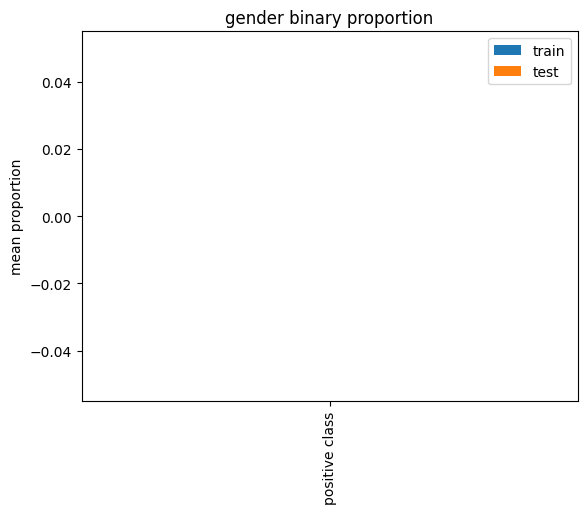

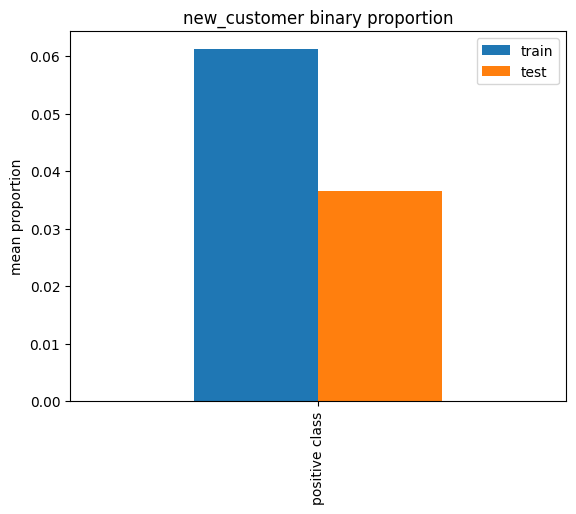

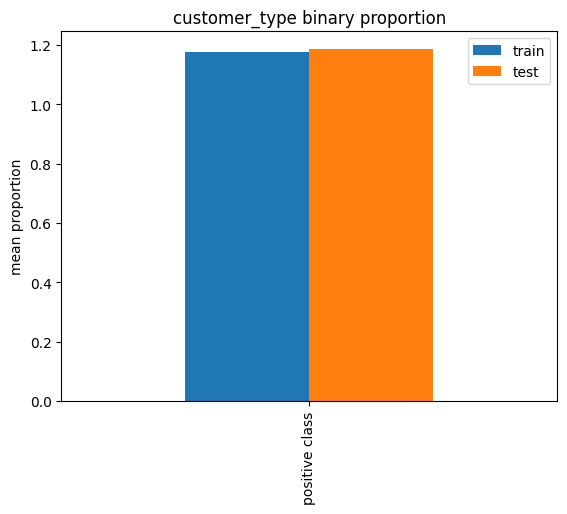

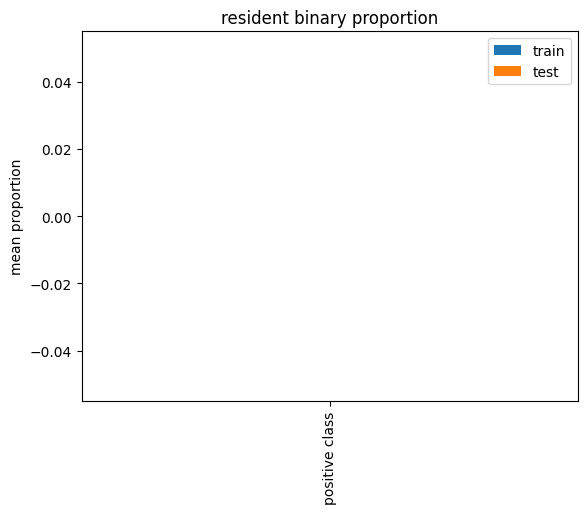

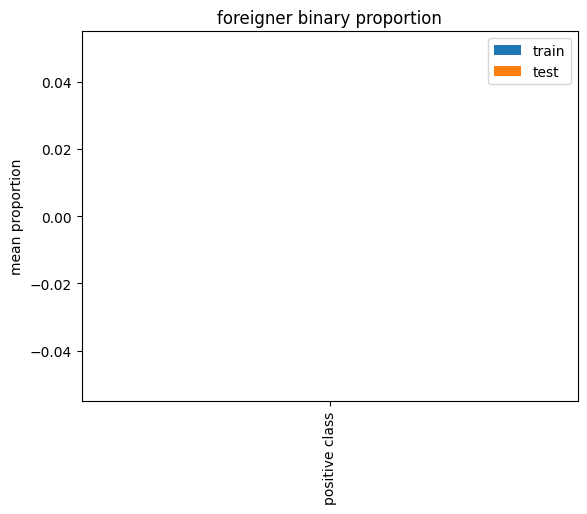

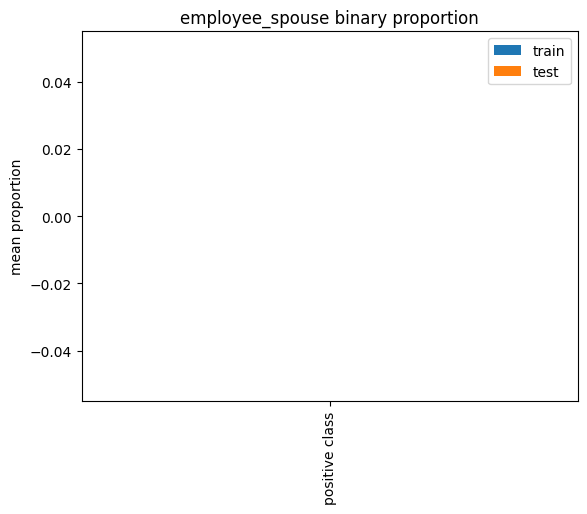

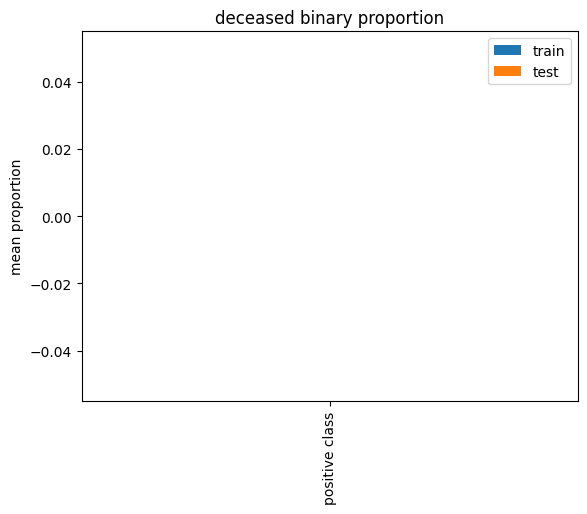

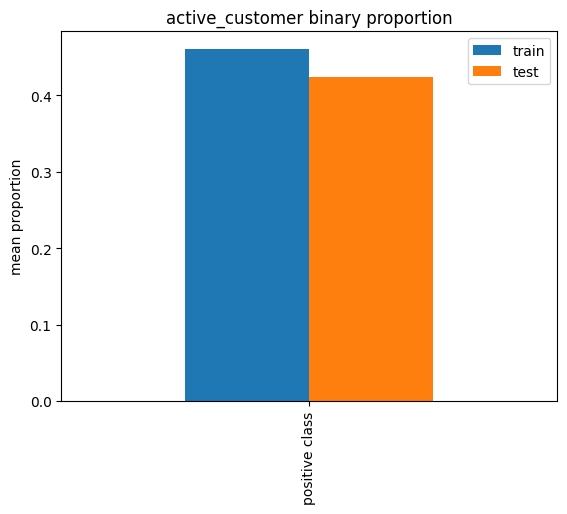

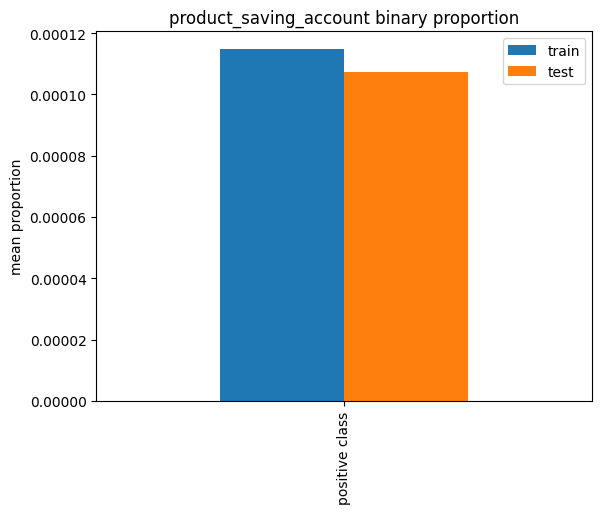

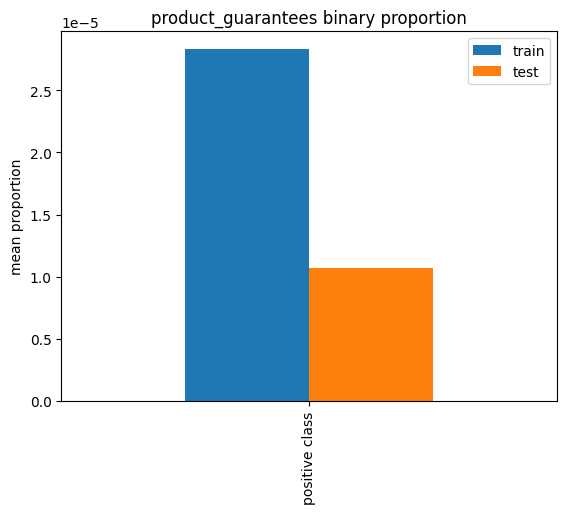

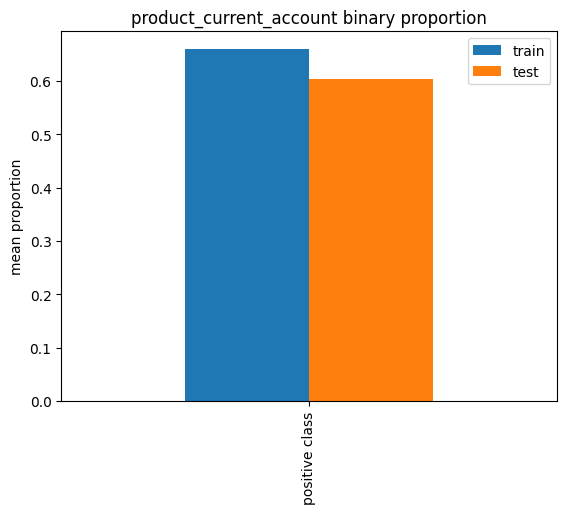

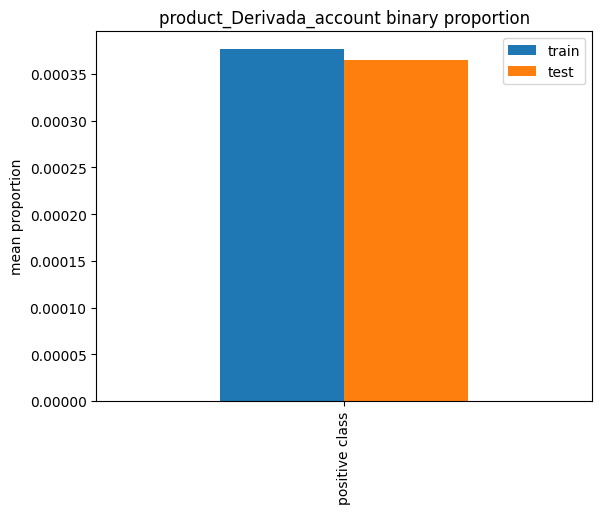

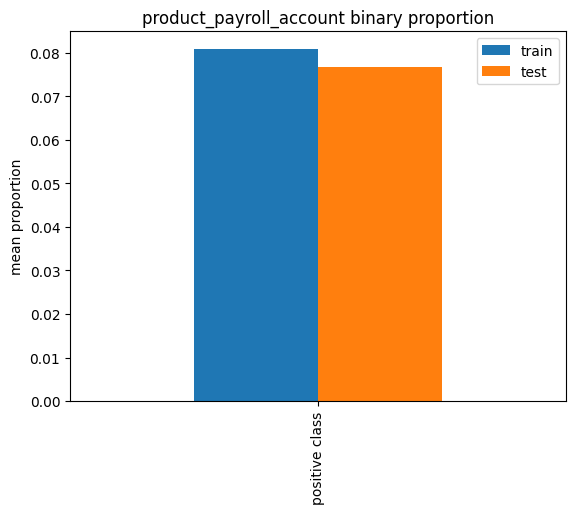

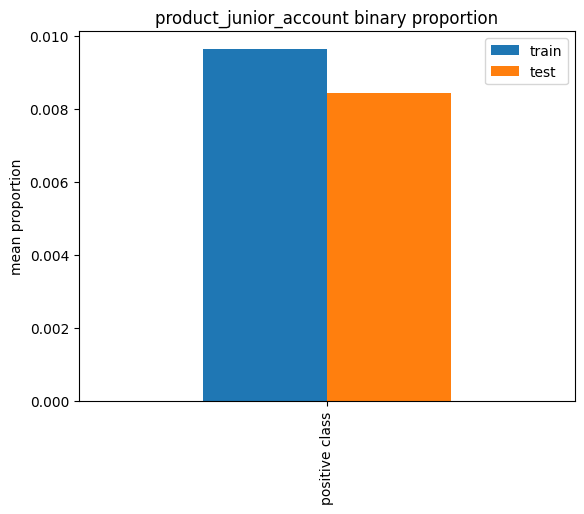

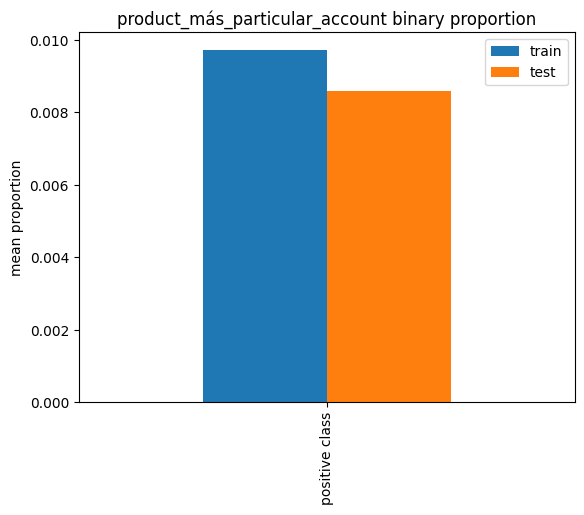

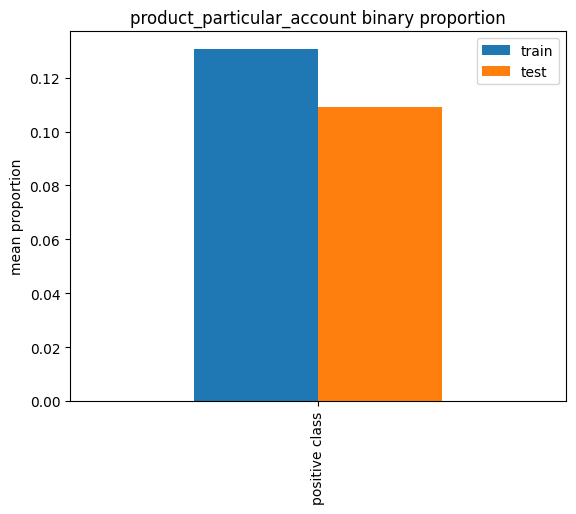

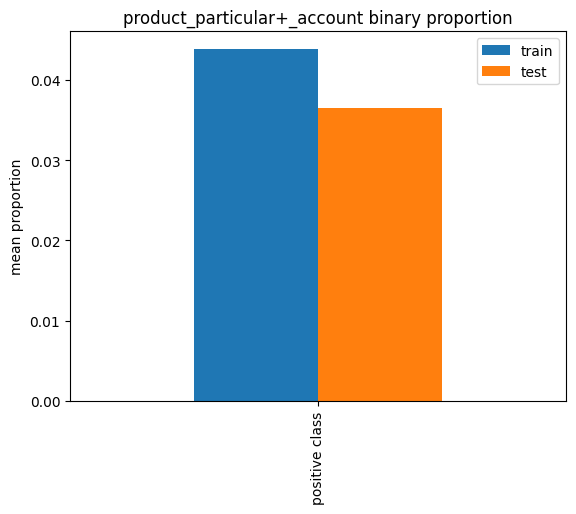

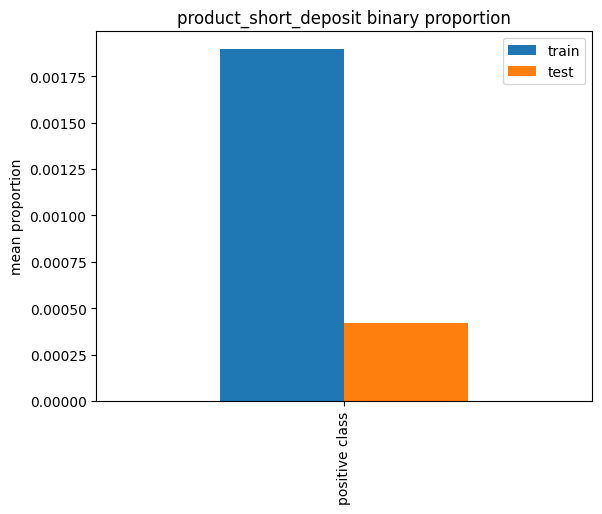

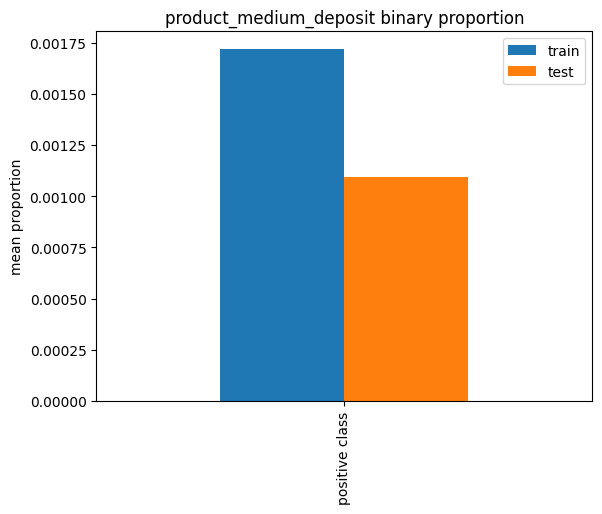

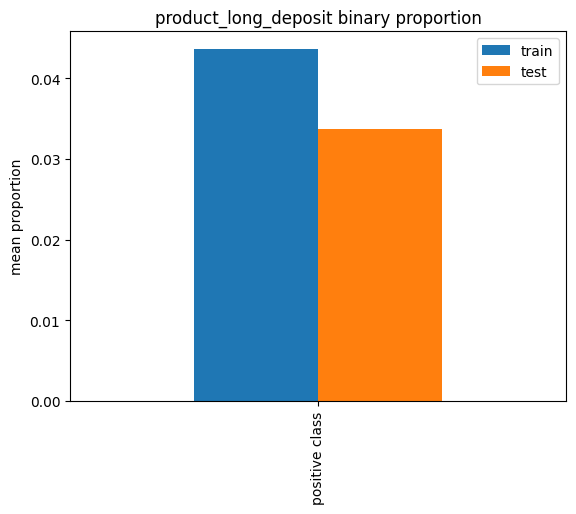

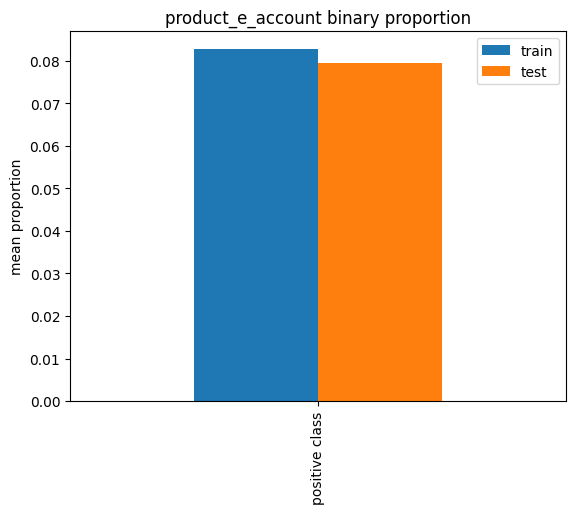

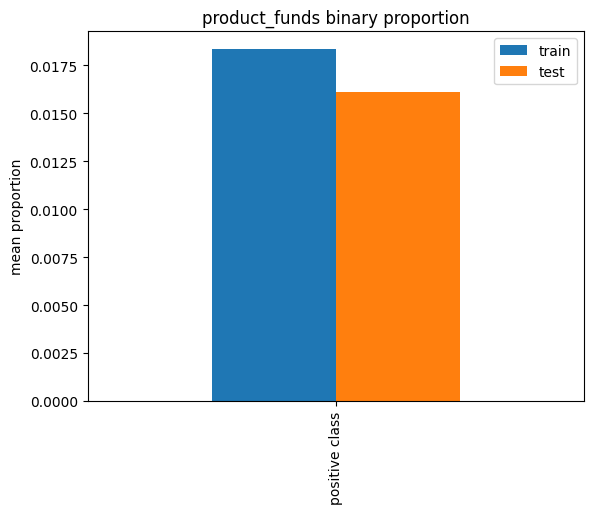

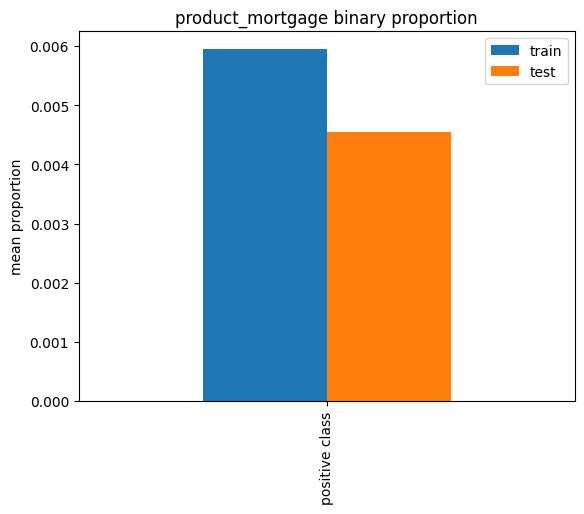

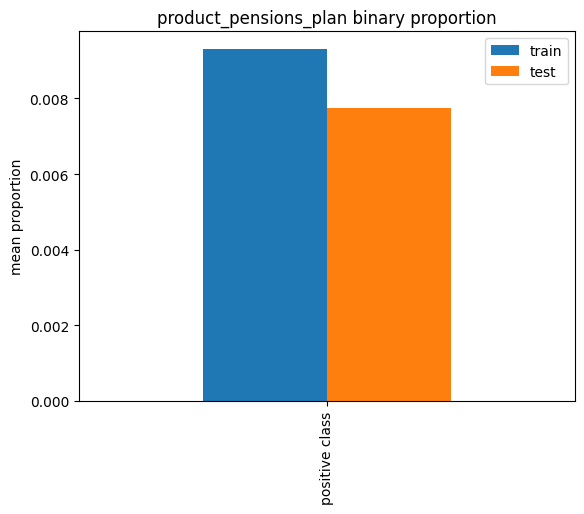

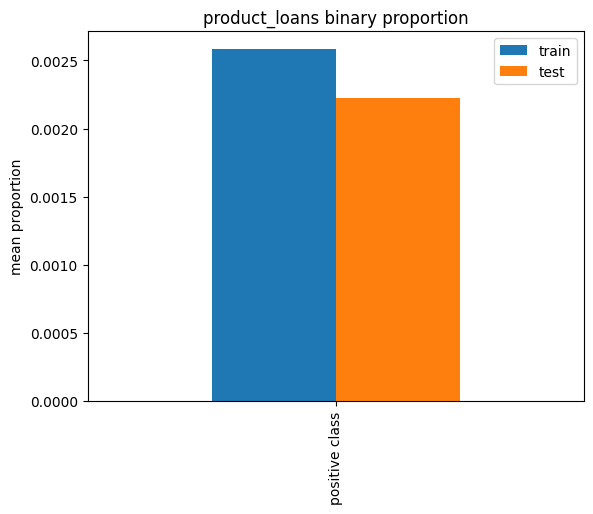

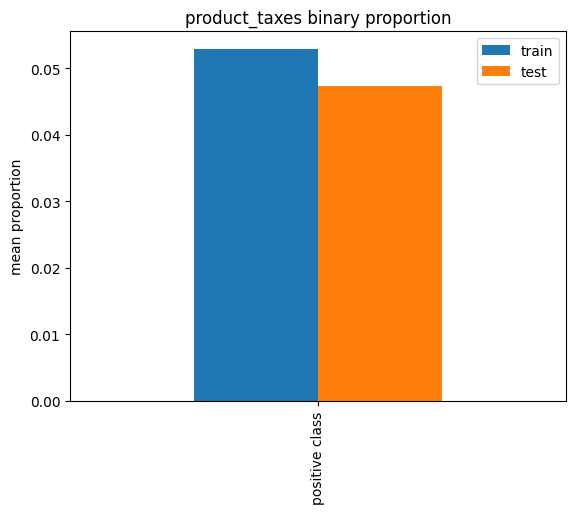

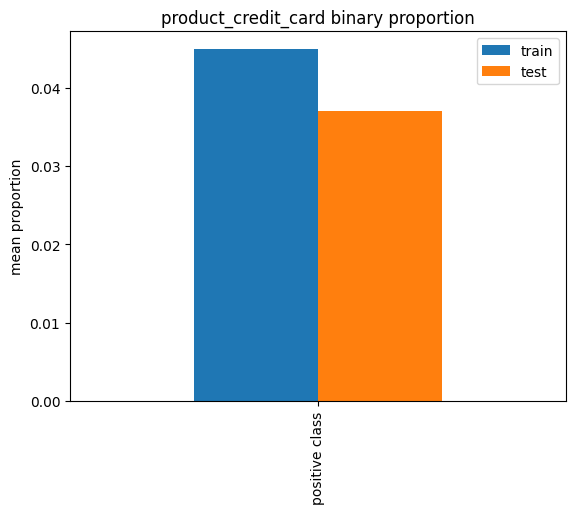

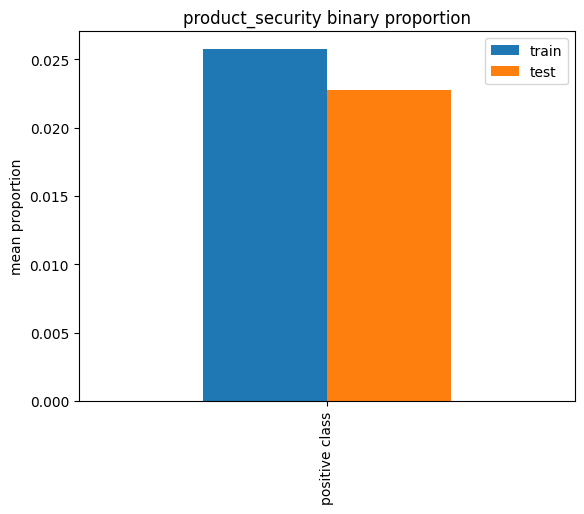

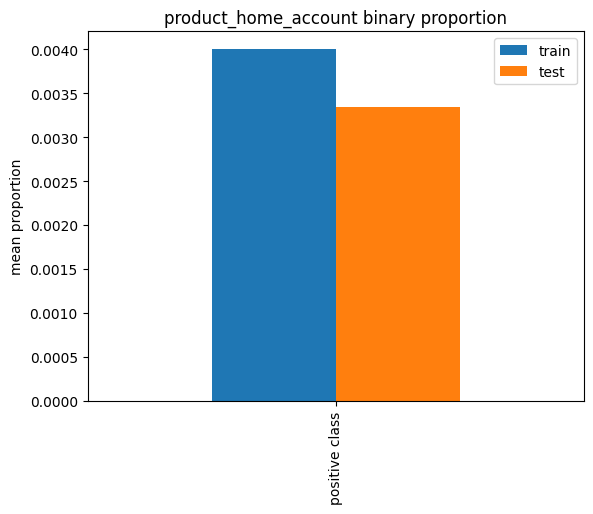

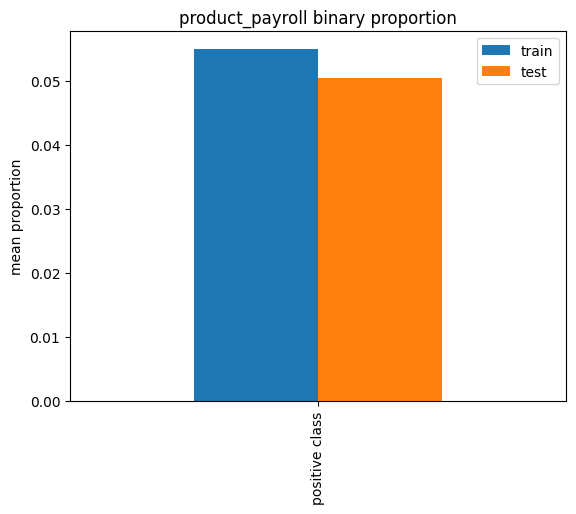

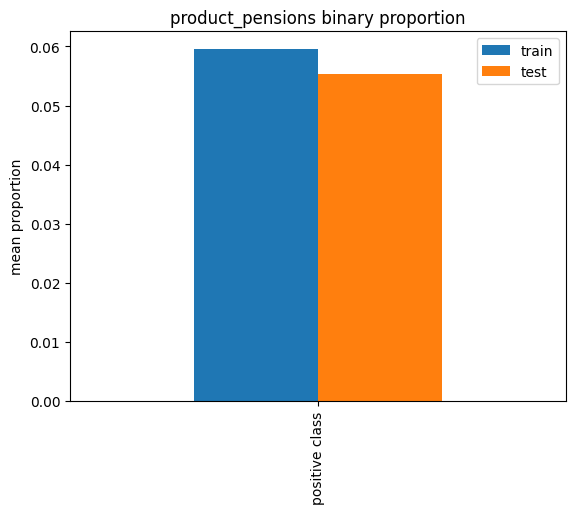

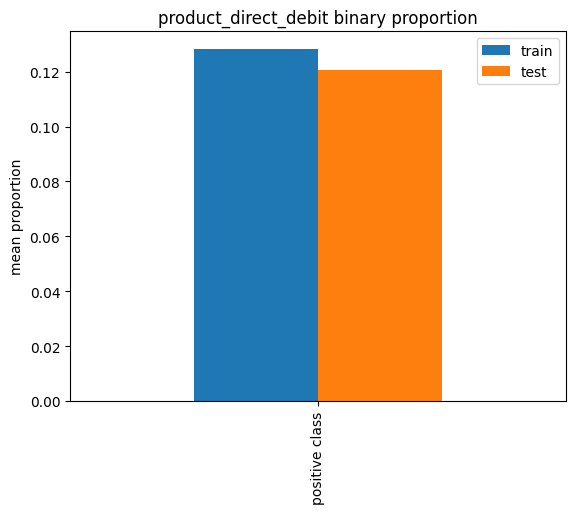

In [ ]:
for col in binary_cols:

    train_mean = pd.to_numeric(df_train[col], errors='coerce').mean()
    test_mean  = pd.to_numeric(df_test[col], errors='coerce').mean()

    compare = pd.DataFrame({
        'train': [train_mean],
        'test': [test_mean]
    })

    compare.plot(kind='bar')

    plt.title(f'{col} binary proportion')
    plt.ylabel('mean proportion')

    plt.xticks([0], ['positive class'])

    plt.show()

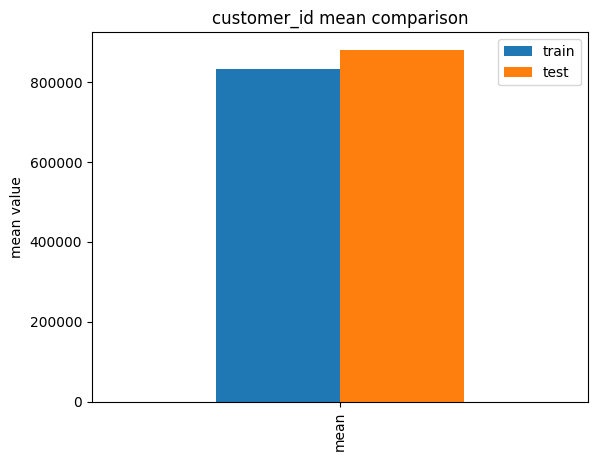

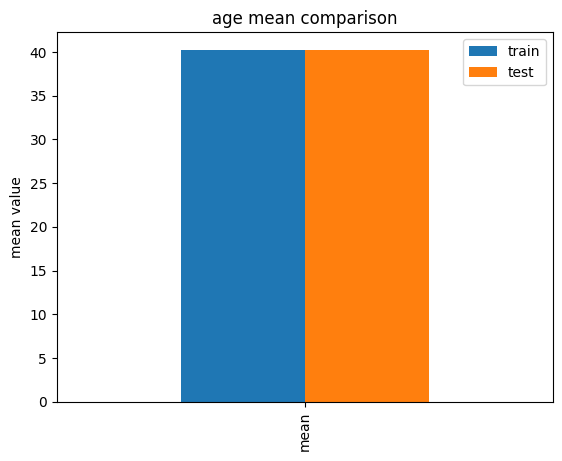

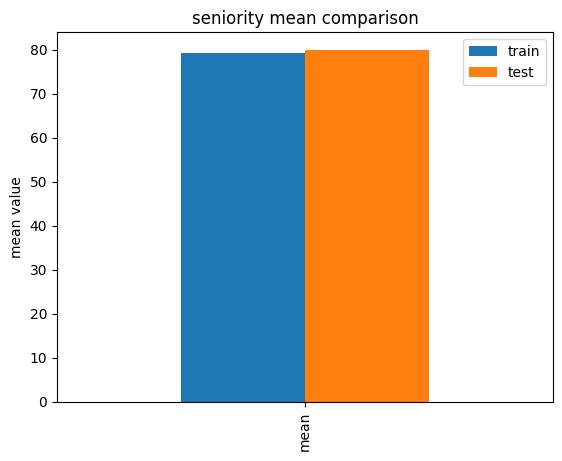

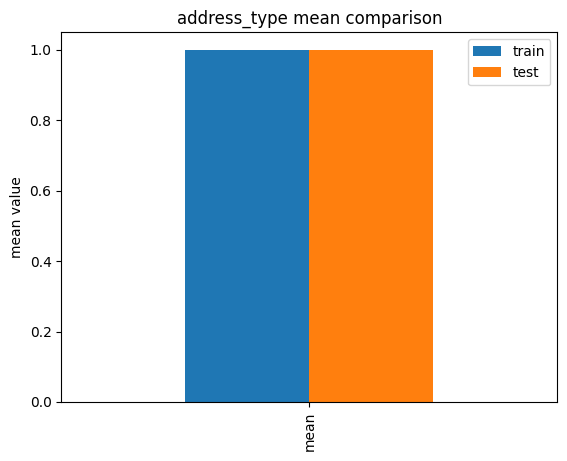

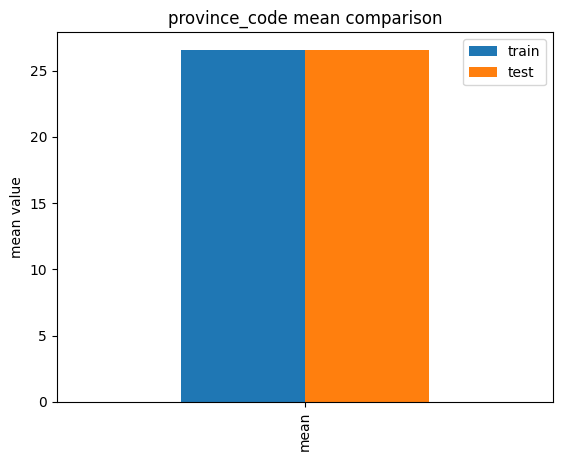

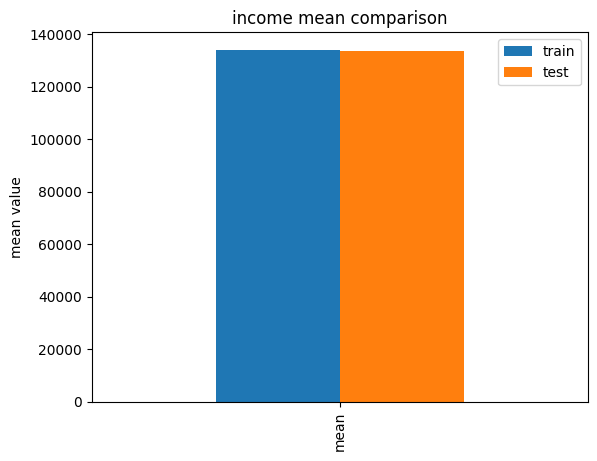

In [ ]:
for col in numeric_cols:

    train_mean = df_train[col].mean()
    test_mean = df_test[col].mean()

    compare = pd.DataFrame({
        'train': [train_mean],
        'test': [test_mean]
    })

    compare.plot(kind='bar')

    plt.title(f'{col} mean comparison')
    plt.ylabel('mean value')
    plt.xticks([0], ['mean'])

    plt.show()

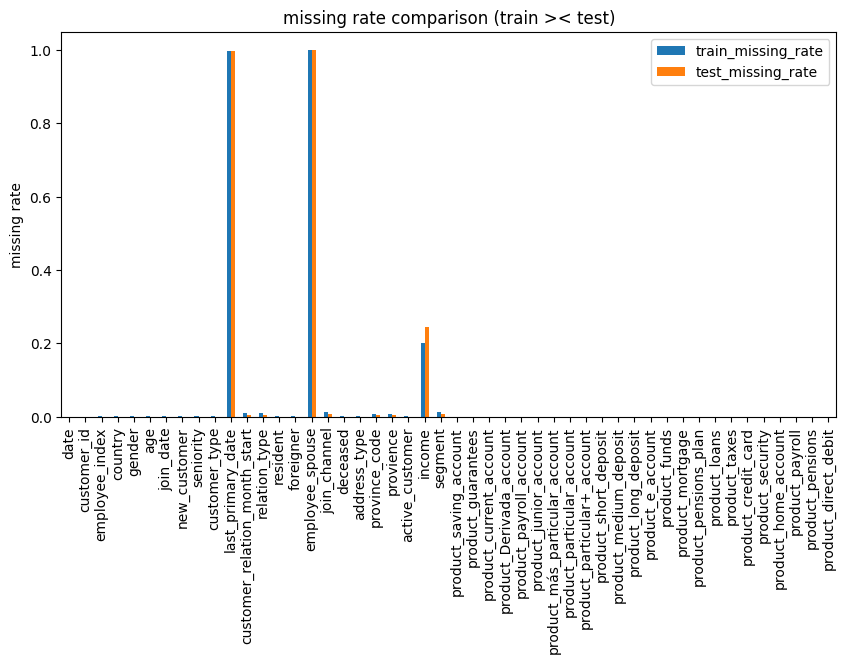

In [ ]:
train_missing=df_train.isnull().mean()
test_missing=df_test.isnull().mean()
missing_compare=pd.DataFrame({
    'train_missing_rate': train_missing,
    'test_missing_rate': test_missing
})
missing_compare.plot(kind='bar', figsize=(10, 5))
plt.title('missing rate comparison (train >< test)')
plt.ylabel('missing rate')
plt.xticks(rotation=90)
plt.show()

Column last_primary_date, and employee_spouse have same missing rate.
Missing rate in training file is higher than testing file at column customer_relation_month_start, relation_type, province code, province, and segment.
Missing rate in testing file is higher than training file at column income